✅ CELL 0 — Mount Drive, set paths, list raw parquet files

In [ ]:
!pip -q install ecos


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 5.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/Thesis"
RAW_DIR  = os.path.join(BASE_DIR, "raw_parquet")

assert os.path.isdir(RAW_DIR), f"raw_parquet folder not found at: {RAW_DIR}"

files = sorted([f for f in os.listdir(RAW_DIR) if f.lower().endswith(".parquet")])
print("raw_parquet files:")
for f in files:
    print(" -", f)


Mounted at /content/drive
raw_parquet files:
 - ff.parquet
 - gw.parquet
 - prices.parquet
 - volumes.parquet


✅ CELL 1 — Loaders (auto-detect panel files + standardize columns)

In [ ]:
def _standardize_cols(df: pd.DataFrame) -> pd.DataFrame:
    # Normalize common column names
    rename = {}
    cols = list(df.columns)

    # Date
    if "Date" not in cols:
        for c in cols:
            if c.lower() in ["date", "datetime", "time"]:
                rename[c] = "Date"
                break

    # ticker
    if "ticker" not in cols:
        for c in cols:
            if c.lower() in ["ticker", "symbol", "permno", "secid"]:
                rename[c] = "ticker"
                break

    df = df.rename(columns=rename)

    # If Date is index, bring it back
    if "Date" not in df.columns and df.index.name and df.index.name.lower() in ["date","datetime","time"]:
        df = df.reset_index()

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
    if "ticker" in df.columns:
        df["ticker"] = df["ticker"].astype(str)

    return df

def load_parquet_by_keyword(raw_dir: str, keyword_regex: str) -> pd.DataFrame:
    patt = re.compile(keyword_regex, re.IGNORECASE)
    cands = [f for f in os.listdir(raw_dir) if f.lower().endswith(".parquet") and patt.search(f)]
    assert len(cands) >= 1, f"No parquet found matching regex: {keyword_regex}"
    # pick the shortest / most direct match
    cands = sorted(cands, key=lambda x: (len(x), x))
    path = os.path.join(raw_dir, cands[0])
    df = pd.read_parquet(path)
    df = _standardize_cols(df)
    print(f"Loaded: {cands[0]} | shape={df.shape}")
    return df

# Try common naming patterns; adjust regex if your filenames differ
prices  = load_parquet_by_keyword(RAW_DIR, r"price|prices|close|adj")
volumes = load_parquet_by_keyword(RAW_DIR, r"volume|volumes")
ff      = load_parquet_by_keyword(RAW_DIR, r"\bff\b|fama|french|factors")
gw      = load_parquet_by_keyword(RAW_DIR, r"\bgw\b|goyal|welch|macro")


Loaded: prices.parquet | shape=(6434, 504)
Loaded: volumes.parquet | shape=(6434, 505)
Loaded: ff.parquet | shape=(6434, 11)
Loaded: gw.parquet | shape=(6434, 16)


✅ CELL 2 — Ensure prices are in LONG format (Date, ticker, close)

In [ ]:
def ensure_long_prices(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Case A: already long
    if {"Date", "ticker"}.issubset(df.columns):
        # find price column
        price_col = None
        for c in ["adj_close", "Adj Close", "close", "Close", "price", "Price"]:
            if c in df.columns:
                price_col = c
                break
        if price_col is None:
            # last resort: if exactly one numeric column besides Date/ticker
            num_cols = [c for c in df.columns if c not in ["Date","ticker"] and pd.api.types.is_numeric_dtype(df[c])]
            assert len(num_cols) >= 1, "Could not infer price column in long prices dataframe."
            price_col = num_cols[0]

        out = df[["Date","ticker", price_col]].rename(columns={price_col:"close"}).copy()
        out = out.dropna(subset=["Date","ticker","close"])
        return out.sort_values(["ticker","Date"]).reset_index(drop=True)

    # Case B: wide: Date + many tickers columns
    assert "Date" in df.columns or df.index.name is not None, "Wide prices must have Date column or Date index."
    if "Date" not in df.columns:
        df = df.reset_index()

    id_vars = ["Date"]
    value_vars = [c for c in df.columns if c not in id_vars]
    out = df.melt(id_vars=id_vars, value_vars=value_vars, var_name="ticker", value_name="close")
    out["Date"] = pd.to_datetime(out["Date"])
    out["ticker"] = out["ticker"].astype(str)
    out = out.dropna(subset=["close"])
    return out.sort_values(["ticker","Date"]).reset_index(drop=True)

prices_long = ensure_long_prices(prices)
print(prices_long.head())
print("prices_long:", prices_long.shape)


        Date ticker      close
0 1999-11-30      A  25.312435
1 1999-12-01      A  25.762442
2 1999-12-02      A  26.474928
3 1999-12-03      A  26.699932
4 1999-12-06      A  27.449924
prices_long: (3236302, 3)


✅ CELL 3 — Build DAILY returns + forward targets (no leakage)

In [ ]:
prices_long = prices_long.sort_values(["ticker","Date"]).reset_index(drop=True)

# backward returns (for risk features etc.)
prices_long["ret_1d"]  = prices_long.groupby("ticker")["close"].pct_change(1)
prices_long["ret_5d"]  = prices_long.groupby("ticker")["close"].pct_change(5)
prices_long["ret_21d"] = prices_long.groupby("ticker")["close"].pct_change(21)

# forward returns (targets)
prices_long["ret_1d_fwd"]  = prices_long.groupby("ticker")["close"].shift(-1)  / prices_long["close"] - 1
prices_long["ret_5d_fwd"]  = prices_long.groupby("ticker")["close"].shift(-5)  / prices_long["close"] - 1
prices_long["ret_21d_fwd"] = prices_long.groupby("ticker")["close"].shift(-21) / prices_long["close"] - 1

print(prices_long[["Date","ticker","close","ret_1d","ret_21d","ret_21d_fwd"]].head(10))


        Date ticker      close    ret_1d  ret_21d  ret_21d_fwd
0 1999-11-30      A  25.312435       NaN      NaN     0.878518
1 1999-12-01      A  25.762442  0.017778      NaN     0.800581
2 1999-12-02      A  26.474928  0.027656      NaN     0.631728
3 1999-12-03      A  26.699932  0.008499      NaN     0.494383
4 1999-12-06      A  27.449924  0.028090      NaN     0.363388
5 1999-12-07      A  27.149935 -0.010929      NaN     0.325966
6 1999-12-08      A  27.112436 -0.001381      NaN     0.438451
7 1999-12-09      A  27.487427  0.013831      NaN     0.504775
8 1999-12-10      A  26.849939 -0.023192      NaN     0.519552
9 1999-12-13      A  27.299934  0.016760      NaN     0.464286


✅ CELL 4 — Build the 9 FEATURES (daily, then we’ll take month-end rows)

In [ ]:
# Rolling helpers
TRADING_DAYS = 252

# --- Price-based features ---
g = prices_long.groupby("ticker", group_keys=False)

# lag6: 126d momentum (6 months)
prices_long["lag6"] = g["close"].pct_change(126)

# moving averages ratio
prices_long["sma_63"]  = g["close"].transform(lambda s: s.rolling(63, min_periods=63).mean())
prices_long["sma_126"] = g["close"].transform(lambda s: s.rolling(126, min_periods=126).mean())
prices_long["ma_ratio_63_126"] = (prices_long["sma_63"] / prices_long["sma_126"]) - 1

# zscore price 63d
roll_mean_63 = g["close"].transform(lambda s: s.rolling(63, min_periods=63).mean())
roll_std_63  = g["close"].transform(lambda s: s.rolling(63, min_periods=63).std(ddof=0))
prices_long["zscore_price_63d"] = (prices_long["close"] - roll_mean_63) / (roll_std_63.replace(0, np.nan))

# --- Risk features from daily returns (use ret_1d) ---
r = prices_long["ret_1d"]

# vol (annualized)
prices_long["volatility_21d"]  = g["ret_1d"].transform(lambda s: s.rolling(21, min_periods=21).std(ddof=0) * np.sqrt(TRADING_DAYS))
prices_long["volatility_63d"]  = g["ret_1d"].transform(lambda s: s.rolling(63, min_periods=63).std(ddof=0) * np.sqrt(TRADING_DAYS))

# semi-variance (annualized): mean(min(r,0)^2)*252
def _semi_var_ann(x):
    dn = np.minimum(x, 0.0)
    return np.nanmean(dn*dn) * TRADING_DAYS

prices_long["semi_variance_63d"] = g["ret_1d"].transform(lambda s: s.rolling(63, min_periods=63).apply(_semi_var_ann, raw=True))

# kurtosis over 63d window
prices_long["kurtosis_63d"] = g["ret_1d"].transform(lambda s: s.rolling(63, min_periods=63).kurt())

# Keep only needed cols (daily features)
FEATURES_9 = [
    "lag6",
    "ma_ratio_63_126",
    "zscore_price_63d",
    "alpha_FF_6m",   # placeholder for now
    "alpha_FF_12m",  # placeholder for now
    "volatility_21d",
    "volatility_63d",
    "semi_variance_63d",
    "kurtosis_63d",
]

print("Built 7/9 features (price + risk). Need FF alpha next.")


Built 7/9 features (price + risk). Need FF alpha next.


✅ CELL 5 — Prepare FF factors (daily) and compute rolling alpha (6m, 12m)

In [ ]:
def standardize_ff(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = _standardize_cols(df)

    if "Date" not in df.columns:
        df = df.reset_index()
        df = _standardize_cols(df)

    df["Date"] = pd.to_datetime(df["Date"])

    cols = df.columns.tolist()

    # Detect whether FF5 exists
    has_ff5 = any(c.startswith("FF5_") for c in cols)
    prefix = "FF5_" if has_ff5 else "FF_"

    # Required
    c_mktrf = prefix + "Mkt-RF"
    c_rf    = prefix + "RF"

    assert c_mktrf in cols and c_rf in cols, (
        f"Missing required columns. Expected {c_mktrf} and {c_rf}. "
        f"Available: {cols}"
    )

    # Optional
    optional = []
    for name in ["SMB", "HML", "RMW", "CMA"]:
        c = prefix + name
        if c in cols:
            optional.append(c)

    use = ["Date", c_mktrf, c_rf] + optional
    out = df[use].copy()

    # Rename to standard factor names
    rename_map = {c_mktrf: "MKT_RF", c_rf: "RF"}
    for c in optional:
        rename_map[c] = c.replace(prefix, "")  # SMB/HML/RMW/CMA

    out = out.rename(columns=rename_map)

    # Convert percent to decimals if needed
    for c in ["MKT_RF", "SMB", "HML", "RMW", "CMA", "RF"]:
        if c in out.columns:
            if out[c].abs().median() > 0.5:   # likely percent
                out[c] = out[c] / 100.0

    return out.sort_values("Date").reset_index(drop=True)

ff_std = standardize_ff(ff)
print(ff_std.head())
print("FF standardized columns:", ff_std.columns.tolist())


        Date  MKT_RF       RF     SMB     HML     RMW     CMA
0 1999-11-30 -0.0130  0.00017  0.0046  0.0136  0.0055  0.0076
1 1999-12-01  0.0052  0.00020 -0.0030 -0.0037  0.0008 -0.0019
2 1999-12-02  0.0114  0.00020  0.0024 -0.0086 -0.0087 -0.0058
3 1999-12-03  0.0159  0.00020 -0.0095 -0.0077 -0.0014 -0.0039
4 1999-12-06 -0.0042  0.00020  0.0066 -0.0047 -0.0093 -0.0048
FF standardized columns: ['Date', 'MKT_RF', 'RF', 'SMB', 'HML', 'RMW', 'CMA']


Now compute rolling alpha per ticker.

In [ ]:
import statsmodels.api as sm
# Merge FF into prices_long (daily)
df = prices_long.merge(ff_std, on="Date", how="left")
df = df.sort_values(["ticker","Date"]).reset_index(drop=True)

# Excess return for regression
df["excess_ret_1d"] = df["ret_1d"] - df["RF"]

FACTOR_COLS = ["MKT_RF"]
if "SMB" in df.columns: FACTOR_COLS.append("SMB")
if "HML" in df.columns: FACTOR_COLS.append("HML")

def rolling_alpha(group: pd.DataFrame, window: int, annualize: int = 252) -> pd.Series:
    y = group["excess_ret_1d"].values
    X = group[FACTOR_COLS].values
    n = len(group)
    out = np.full(n, np.nan, dtype=float)

    for i in range(window-1, n):
        ys = y[i-window+1:i+1]
        Xs = X[i-window+1:i+1]

        if np.isnan(ys).any() or np.isnan(Xs).any():
            continue

        Xs_ = sm.add_constant(Xs, has_constant="add")
        try:
            beta = np.linalg.lstsq(Xs_, ys, rcond=None)[0]
            alpha_daily = beta[0]
            out[i] = alpha_daily * annualize
        except Exception:
            continue

    return pd.Series(out, index=group.index)

# Compute 6m and 12m alpha
df["alpha_FF_6m"]  = df.groupby("ticker", group_keys=False).apply(lambda g: rolling_alpha(g, window=126))
df["alpha_FF_12m"] = df.groupby("ticker", group_keys=False).apply(lambda g: rolling_alpha(g, window=252))

# Put back into prices_long-like frame
prices_feat = df.copy()

print("✅ alpha_FF_6m / alpha_FF_12m done")
print(prices_feat[["Date","ticker","alpha_FF_6m","alpha_FF_12m"]].dropna().head())


✅ alpha_FF_6m / alpha_FF_12m done
          Date ticker  alpha_FF_6m  alpha_FF_12m
252 2000-11-28      A    -0.043119      0.729276
253 2000-11-29      A     0.206497      0.792384
254 2000-11-30      A     0.137169      0.798130
255 2000-12-01      A     0.245860      0.783411
256 2000-12-04      A     0.386658      0.746013


✅ CELL 6 — Build FINAL “features panel” (daily + month-end panel)

In [ ]:
# Final 9 feature columns (now real)
FEATURES_9 = [
    "lag6",
    "ma_ratio_63_126",
    "zscore_price_63d",
    "alpha_FF_6m",
    "alpha_FF_12m",
    "volatility_21d",
    "volatility_63d",
    "semi_variance_63d",
    "kurtosis_63d",
]

panel_features_daily = prices_feat[["Date","ticker"] + FEATURES_9].copy()
panel_features_daily = panel_features_daily.replace([np.inf, -np.inf], np.nan)

# Define month_end + rebalance_date as last trading day of month
panel_features_daily["month_end"] = panel_features_daily["Date"].dt.to_period("M").dt.to_timestamp("M")
reb = panel_features_daily.groupby("month_end")["Date"].max().rename("rebalance_date")
panel_features_daily = panel_features_daily.merge(reb, on="month_end", how="left")

panel_features_monthly = panel_features_daily.loc[
    panel_features_daily["Date"] == panel_features_daily["rebalance_date"],
    ["Date","month_end","ticker"] + FEATURES_9
].sort_values(["month_end","ticker"]).reset_index(drop=True)

print("panel_features_daily:", panel_features_daily.shape)
print("panel_features_monthly:", panel_features_monthly.shape)
print(panel_features_monthly.head())


panel_features_daily: (3236302, 13)
panel_features_monthly: (154924, 12)
        Date  month_end ticker  lag6  ma_ratio_63_126  zscore_price_63d  \
0 1999-11-30 1999-11-30      A   NaN              NaN               NaN   
1 1999-11-30 1999-11-30   AAPL   NaN              NaN               NaN   
2 1999-11-30 1999-11-30   ABBV   NaN              NaN               NaN   
3 1999-11-30 1999-11-30   ABNB   NaN              NaN               NaN   
4 1999-11-30 1999-11-30    ABT   NaN              NaN               NaN   

   alpha_FF_6m  alpha_FF_12m  volatility_21d  volatility_63d  \
0          NaN           NaN             NaN             NaN   
1          NaN           NaN             NaN             NaN   
2          NaN           NaN             NaN             NaN   
3          NaN           NaN             NaN             NaN   
4          NaN           NaN             NaN             NaN   

   semi_variance_63d  kurtosis_63d  
0                NaN           NaN  
1                

✅ CELL 7 — Build TARGET panels (separate from features)

In [ ]:
panel_targets_daily = prices_feat[["Date","ticker","ret_1d_fwd","ret_5d_fwd","ret_21d_fwd"]].copy()
panel_targets_daily["month_end"] = panel_targets_daily["Date"].dt.to_period("M").dt.to_timestamp("M")
reb2 = panel_targets_daily.groupby("month_end")["Date"].max().rename("rebalance_date")
panel_targets_daily = panel_targets_daily.merge(reb2, on="month_end", how="left")

panel_targets_monthly = panel_targets_daily.loc[
    panel_targets_daily["Date"] == panel_targets_daily["rebalance_date"],
    ["Date","month_end","ticker","ret_1d_fwd","ret_5d_fwd","ret_21d_fwd"]
].sort_values(["month_end","ticker"]).reset_index(drop=True)

print("panel_targets_daily:", panel_targets_daily.shape)
print("panel_targets_monthly:", panel_targets_monthly.shape)
print(panel_targets_monthly.head())


panel_targets_daily: (3236302, 7)
panel_targets_monthly: (154924, 6)
        Date  month_end ticker  ret_1d_fwd  ret_5d_fwd  ret_21d_fwd
0 1999-11-30 1999-11-30      A    0.017778    0.072593     0.878518
1 1999-11-30 1999-11-30   AAPL    0.053001    0.203703     0.024903
2 1999-11-30 1999-11-30   ABBV    0.000000    0.000000     0.000000
3 1999-11-30 1999-11-30   ABNB    0.000000    0.000000     0.000000
4 1999-11-30 1999-11-30    ABT   -0.014803   -0.057566    -0.034540


✅ CELL 8 — Save to separate “panels” (Parquet outputs)

In [ ]:
OUT_DIR = os.path.join(BASE_DIR, "panel_data_v4")
os.makedirs(OUT_DIR, exist_ok=True)

features_daily_path   = os.path.join(OUT_DIR, "panel_features_daily.parquet")
features_monthly_path = os.path.join(OUT_DIR, "panel_features_monthly.parquet")
targets_daily_path    = os.path.join(OUT_DIR, "panel_targets_daily.parquet")
targets_monthly_path  = os.path.join(OUT_DIR, "panel_targets_monthly.parquet")

panel_features_daily.to_parquet(features_daily_path, index=False)
panel_features_monthly.to_parquet(features_monthly_path, index=False)
panel_targets_daily.to_parquet(targets_daily_path, index=False)
panel_targets_monthly.to_parquet(targets_monthly_path, index=False)

print("✅ Saved:")
print(" -", features_daily_path)
print(" -", features_monthly_path)
print(" -", targets_daily_path)
print(" -", targets_monthly_path)


✅ Saved:
 - /content/drive/MyDrive/Thesis/panel_data_v4/panel_features_daily.parquet
 - /content/drive/MyDrive/Thesis/panel_data_v4/panel_features_monthly.parquet
 - /content/drive/MyDrive/Thesis/panel_data_v4/panel_targets_daily.parquet
 - /content/drive/MyDrive/Thesis/panel_data_v4/panel_targets_monthly.parquet


NaNs Handeling

In [ ]:
# =========================
# NaN Policy (best practice)
# =========================
MIN_HISTORY_DAYS = 252   # ensures 12m alpha + 126d MA ratio etc. are stable
MIN_FEATURES_NONNAN = 9  # require all 9 features present at month-end rows

FEATURES_9 = [
    "lag6",
    "ma_ratio_63_126",
    "zscore_price_63d",
    "alpha_FF_6m",
    "alpha_FF_12m",
    "volatility_21d",
    "volatility_63d",
    "semi_variance_63d",
    "kurtosis_63d",
]

TARGET_COLS = ["ret_1d_fwd", "ret_5d_fwd", "ret_21d_fwd"]

# Ensure sorted
prices_feat = prices_feat.sort_values(["ticker","Date"]).reset_index(drop=True)

# Add "age" = number of trading days since ticker start in this dataset
prices_feat["age_days"] = prices_feat.groupby("ticker").cumcount() + 1

# Warmup rule: only allow rows once enough history exists
prices_feat["warmup_ok"] = prices_feat["age_days"] >= MIN_HISTORY_DAYS

print("✅ Warmup threshold:", MIN_HISTORY_DAYS)
print(prices_feat[["ticker","Date","age_days","warmup_ok"]].head(5))


✅ Warmup threshold: 252
  ticker       Date  age_days  warmup_ok
0      A 1999-11-30         1      False
1      A 1999-12-01         2      False
2      A 1999-12-02         3      False
3      A 1999-12-03         4      False
4      A 1999-12-06         5      False


In [ ]:
# =========================
# Daily features with masks
# =========================
panel_features_daily = prices_feat[["Date","ticker","age_days","warmup_ok"] + FEATURES_9].copy()

# mask: all 9 features available
panel_features_daily["feat_non_nan"] = panel_features_daily[FEATURES_9].notna().sum(axis=1)
panel_features_daily["features_ok"] = (
    panel_features_daily["warmup_ok"] &
    (panel_features_daily["feat_non_nan"] >= MIN_FEATURES_NONNAN)
)

# DON'T fill feature NaNs here. Keep NaNs and filter later.
print(panel_features_daily[["feat_non_nan","warmup_ok","features_ok"]].describe())
print("features_ok rate:", panel_features_daily["features_ok"].mean())


       feat_non_nan
count  3.236302e+06
mean   8.742114e+00
std    9.703008e-01
min    0.000000e+00
25%    9.000000e+00
50%    9.000000e+00
75%    9.000000e+00
max    9.000000e+00
features_ok rate: 0.8515994490007422


In [ ]:
panel_targets_daily = prices_feat[["Date","ticker"] + TARGET_COLS].copy()

# targets mask: requires target available
for t in TARGET_COLS:
    panel_targets_daily[f"{t}_ok"] = panel_targets_daily[t].notna()

print(panel_targets_daily[[f"{t}_ok" for t in TARGET_COLS]].mean())


ret_1d_fwd_ok     0.999845
ret_5d_fwd_ok     0.999223
ret_21d_fwd_ok    0.996736
dtype: float64


In [ ]:
# =========================
# Month-end alignment
# =========================
def add_month_end_calendar(df):
    df = df.copy()
    df["month_end"] = df["Date"].dt.to_period("M").dt.to_timestamp("M")
    reb = df.groupby("month_end")["Date"].max().rename("rebalance_date")
    return df.merge(reb, on="month_end", how="left")

panel_features_daily_cal = add_month_end_calendar(panel_features_daily)
panel_targets_daily_cal  = add_month_end_calendar(panel_targets_daily)

# Month-end only
panel_features_monthly = panel_features_daily_cal.loc[
    panel_features_daily_cal["Date"] == panel_features_daily_cal["rebalance_date"],
    ["Date","month_end","ticker","age_days","warmup_ok","feat_non_nan","features_ok"] + FEATURES_9
].sort_values(["month_end","ticker"]).reset_index(drop=True)

panel_targets_monthly = panel_targets_daily_cal.loc[
    panel_targets_daily_cal["Date"] == panel_targets_daily_cal["rebalance_date"],
    ["Date","month_end","ticker"] + TARGET_COLS + [f"{t}_ok" for t in TARGET_COLS]
].sort_values(["month_end","ticker"]).reset_index(drop=True)

# Apply policy: keep only rows where features are ok
panel_features_monthly_clean = panel_features_monthly[panel_features_monthly["features_ok"]].copy()

print("Monthly features raw:", panel_features_monthly.shape)
print("Monthly features clean:", panel_features_monthly_clean.shape)
print(panel_features_monthly_clean.head())


Monthly features raw: (154924, 16)
Monthly features clean: (131950, 16)
           Date  month_end ticker  age_days  warmup_ok  feat_non_nan  \
6036 2000-11-30 2000-11-30      A       255       True             9   
6037 2000-11-30 2000-11-30   AAPL       255       True             9   
6040 2000-11-30 2000-11-30    ABT       255       True             9   
6041 2000-11-30 2000-11-30   ACGL       255       True             9   
6043 2000-11-30 2000-11-30   ADBE       255       True             9   

      features_ok      lag6  ma_ratio_63_126  zscore_price_63d  alpha_FF_6m  \
6036         True -0.361621        -0.100883          0.529739     0.137169   
6037         True -0.643484        -0.242503         -0.864109    -0.025470   
6040         True  0.419089         0.086791          1.572260     0.419827   
6041         True -0.024390         0.002740         -1.544190    -0.153112   
6043         True  0.014375         0.079582         -1.563609     1.358493   

      alpha_FF_12m  

In [ ]:
panel_monthly_model = panel_features_monthly_clean.merge(
    panel_targets_monthly[["month_end","ticker"] + TARGET_COLS],
    on=["month_end","ticker"],
    how="inner"
)

# For a chosen horizon (example: 21d forward return)
panel_monthly_model = panel_monthly_model.dropna(subset=["ret_21d_fwd"])
print("✅ panel_monthly_model shape:", panel_monthly_model.shape)
print(panel_monthly_model.head())


✅ panel_monthly_model shape: (130944, 19)
        Date  month_end ticker  age_days  warmup_ok  feat_non_nan  \
0 2000-11-30 2000-11-30      A       255       True             9   
1 2000-11-30 2000-11-30   AAPL       255       True             9   
2 2000-11-30 2000-11-30    ABT       255       True             9   
3 2000-11-30 2000-11-30   ACGL       255       True             9   
4 2000-11-30 2000-11-30   ADBE       255       True             9   

   features_ok      lag6  ma_ratio_63_126  zscore_price_63d  alpha_FF_6m  \
0         True -0.361621        -0.100883          0.529739     0.137169   
1         True -0.643484        -0.242503         -0.864109    -0.025470   
2         True  0.419089         0.086791          1.572260     0.419827   
3         True -0.024390         0.002740         -1.544190    -0.153112   
4         True  0.014375         0.079582         -1.563609     1.358493   

   alpha_FF_12m  volatility_21d  volatility_63d  semi_variance_63d  \
0      0.798130 

In [ ]:
import numpy as np
import pandas as pd

def _require(name):
    if name not in globals():
        raise NameError(f"Missing required object: {name}. Run the previous cells that create it.")

# ---- Required objects ----
for nm in [
    "panel_features_daily_cal",
    "panel_features_monthly",
    "panel_features_monthly_clean",
    "panel_targets_monthly",
    "panel_monthly_model",
    "FEATURES_9",
    "TARGET_COLS",
]:
    _require(nm)

print("========================================")
print("SANITY CHECK DASHBOARD")
print("========================================")

# -------------------------
# 1) Shapes + coverage
# -------------------------
print("\n[1] SHAPES + COVERAGE")
def _shape(df, name):
    print(f"  {name:30s} shape={df.shape} | months={df['month_end'].nunique() if 'month_end' in df.columns else 'NA'} | tickers={df['ticker'].nunique() if 'ticker' in df.columns else 'NA'}")

_shape(panel_features_monthly, "panel_features_monthly (raw)")
_shape(panel_features_monthly_clean, "panel_features_monthly_clean")
_shape(panel_targets_monthly, "panel_targets_monthly")
_shape(panel_monthly_model, "panel_monthly_model (merged)")

print("\n  Date range (monthly model):",
      panel_monthly_model["month_end"].min(), "→", panel_monthly_model["month_end"].max())

# -------------------------
# 2) Missingness summary
# -------------------------
print("\n[2] MISSINGNESS SUMMARY (MONTHLY RAW FEATURES)")
miss = panel_features_monthly[FEATURES_9].isna().mean().sort_values(ascending=False)
print(miss.to_string())

print("\n  Clean filter kept % of rows:",
      round(len(panel_features_monthly_clean) / max(1, len(panel_features_monthly)) * 100, 2), "%")

# missingness by month (top 6 worst months)
print("\n  Worst months by missing feature fraction:")
month_miss = panel_features_monthly.groupby("month_end")[FEATURES_9].apply(lambda x: x.isna().mean().mean())
print(month_miss.sort_values(ascending=False).head(6).to_string())

# -------------------------
# 3) Per-feature distribution sanity
# -------------------------
print("\n[3] FEATURE DISTRIBUTION SANITY (CLEAN MONTHLY)")
desc = panel_features_monthly_clean[FEATURES_9].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).T
# add extreme counts
for c in FEATURES_9:
    s = panel_features_monthly_clean[c]
    desc.loc[c, "n_inf"] = np.isinf(s).sum()
    desc.loc[c, "n_nan"] = s.isna().sum()
print(desc[["count","mean","std","min","1%","5%","50%","95%","99%","max","n_nan","n_inf"]].to_string())

# -------------------------
# 4) Target sanity (forward returns)
# -------------------------
print("\n[4] TARGET SANITY (MONTHLY)")
tdesc = panel_targets_monthly[TARGET_COLS].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).T
print(tdesc[["count","mean","std","min","1%","5%","50%","95%","99%","max"]].to_string())

# check target ok rates if present
ok_cols = [c for c in panel_targets_monthly.columns if c.endswith("_ok")]
if ok_cols:
    print("\n  Target availability rates:")
    print(panel_targets_monthly[ok_cols].mean().to_string())

# -------------------------
# 5) Alignment check: any duplicated keys? any missing joins?
# -------------------------
print("\n[5] KEY INTEGRITY + ALIGNMENT")
def dup_keys(df, keys, name):
    dups = df.duplicated(subset=keys).sum()
    print(f"  Duplicated keys in {name}: {dups}")

dup_keys(panel_features_monthly, ["month_end","ticker"], "features_monthly")
dup_keys(panel_targets_monthly, ["month_end","ticker"], "targets_monthly")
dup_keys(panel_monthly_model, ["month_end","ticker"], "monthly_model")

# check join coverage (how many feature rows have targets and vice versa)
feat_keys = panel_features_monthly_clean[["month_end","ticker"]].drop_duplicates()
tgt_keys  = panel_targets_monthly[["month_end","ticker"]].drop_duplicates()
merged_keys = panel_monthly_model[["month_end","ticker"]].drop_duplicates()

feat_only = len(feat_keys.merge(tgt_keys, on=["month_end","ticker"], how="left", indicator=True).query("_merge=='left_only'"))
tgt_only  = len(tgt_keys.merge(feat_keys, on=["month_end","ticker"], how="left", indicator=True).query("_merge=='left_only'"))
print(f"  Feature keys with NO target match: {feat_only}")
print(f"  Target keys with NO feature match: {tgt_only}")
print(f"  Merged keys count: {len(merged_keys)}")

# -------------------------
# 6) Leakage sniff test (fast + practical)
#    Correlation of features with target at month-end
# -------------------------
print("\n[6] LEAKAGE SNIFF TEST (FEATURE ↔ TARGET CORR)")
# Use ret_21d_fwd if present, else first target
target_for_test = "ret_21d_fwd" if "ret_21d_fwd" in TARGET_COLS else TARGET_COLS[0]
tmp = panel_monthly_model[FEATURES_9 + [target_for_test]].dropna()
corrs = tmp.corr(numeric_only=True)[target_for_test].drop(target_for_test).sort_values(key=lambda s: s.abs(), ascending=False)
print(f"  Using target: {target_for_test}")
print(corrs.head(12).to_string())

# Flag suspiciously high abs corr (you can tune threshold)
susp = corrs[abs(corrs) > 0.6]
if len(susp):
    print("\n  ⚠️ Suspiciously high |corr| > 0.60:")
    print(susp.to_string())
else:
    print("\n  ✅ No extremely high correlations detected (>0.60).")

# -------------------------
# 7) Ticker coverage stability over time
# -------------------------
print("\n[7] TICKER COVERAGE OVER TIME (CLEAN MONTHLY)")
cov = panel_features_monthly_clean.groupby("month_end")["ticker"].nunique()
print("  Ticker count summary:")
print(cov.describe().to_string())
print("\n  Lowest coverage months:")
print(cov.sort_values().head(6).to_string())

print("\n========================================")
print("DONE ✅")
print("========================================")


SANITY CHECK DASHBOARD

[1] SHAPES + COVERAGE
  panel_features_monthly (raw)   shape=(154924, 16) | months=308 | tickers=503
  panel_features_monthly_clean   shape=(131950, 16) | months=296 | tickers=503
  panel_targets_monthly          shape=(154924, 9) | months=308 | tickers=503
  panel_monthly_model (merged)   shape=(130944, 19) | months=294 | tickers=503

  Date range (monthly model): 2000-11-30 00:00:00 → 2025-04-30 00:00:00

[2] MISSINGNESS SUMMARY (MONTHLY RAW FEATURES)
zscore_price_63d     0.127617
alpha_FF_12m         0.038961
lag6                 0.019481
ma_ratio_63_126      0.019481
alpha_FF_6m          0.019481
volatility_63d       0.012987
semi_variance_63d    0.012987
kurtosis_63d         0.012987
volatility_21d       0.003247

  Clean filter kept % of rows: 85.17 %

  Worst months by missing feature fraction:
month_end
1999-11-30    1.000000
2000-01-31    0.888889
1999-12-31    0.888889
2000-02-29    0.811133
2000-03-31    0.477579
2000-04-30    0.477358

[3] FEATURE DI

In [ ]:
# =========================
# Freeze + Save FINAL PANELS (to Google Drive)
# =========================
import os
import pandas as pd

# ---- REQUIRED OBJECTS ----
# panel_features_monthly_clean : monthly features after warmup + non-NaN filter
# panel_targets_monthly        : monthly forward targets
# FEATURES_9, TARGET_COLS      : lists

assert "panel_features_monthly_clean" in globals(), "panel_features_monthly_clean not found"
assert "panel_targets_monthly" in globals(), "panel_targets_monthly not found"
assert "FEATURES_9" in globals(), "FEATURES_9 not found"
assert "TARGET_COLS" in globals(), "TARGET_COLS not found"

# ---- OUTPUT FOLDER ----
BASE_DIR = "/content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline"
OUT_DIR  = os.path.join(BASE_DIR, "panel_data_frozen_v1")
os.makedirs(OUT_DIR, exist_ok=True)

# ---- SELECT + SORT (clean, minimal, reproducible) ----
features_frozen = panel_features_monthly_clean[["Date","month_end","ticker"] + FEATURES_9].copy()
features_frozen = features_frozen.sort_values(["month_end","ticker"]).reset_index(drop=True)

targets_frozen  = panel_targets_monthly[["Date","month_end","ticker"] + TARGET_COLS].copy()
targets_frozen  = targets_frozen.sort_values(["month_end","ticker"]).reset_index(drop=True)

# ---- SAVE ----
features_path = os.path.join(OUT_DIR, "panel_features_monthly_frozen_v1.parquet")
targets_path  = os.path.join(OUT_DIR, "panel_targets_monthly_frozen_v1.parquet")

features_frozen.to_parquet(features_path, index=False)
targets_frozen.to_parquet(targets_path, index=False)

# ---- MANIFEST (reproducibility) ----
manifest = {
    "features_path": features_path,
    "targets_path": targets_path,
    "n_features_rows": int(features_frozen.shape[0]),
    "n_targets_rows": int(targets_frozen.shape[0]),
    "n_months_features": int(features_frozen["month_end"].nunique()),
    "n_months_targets": int(targets_frozen["month_end"].nunique()),
    "n_tickers_features": int(features_frozen["ticker"].nunique()),
    "n_tickers_targets": int(targets_frozen["ticker"].nunique()),
    "feature_cols": FEATURES_9,
    "target_cols": TARGET_COLS,
    "date_min_features": str(features_frozen["month_end"].min()),
    "date_max_features": str(features_frozen["month_end"].max()),
    "date_min_targets": str(targets_frozen["month_end"].min()),
    "date_max_targets": str(targets_frozen["month_end"].max()),
}

manifest_path = os.path.join(OUT_DIR, "MANIFEST_frozen_v1.json")
import json
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("✅ FROZEN PANELS SAVED")
print("Features:", features_path)
print("Targets: ", targets_path)
print("Manifest:", manifest_path)

print("\nQuick check:")
print("features_frozen:", features_frozen.shape, "| months:", features_frozen["month_end"].nunique(), "| tickers:", features_frozen["ticker"].nunique())
print("targets_frozen: ", targets_frozen.shape,  "| months:", targets_frozen["month_end"].nunique(),  "| tickers:", targets_frozen["ticker"].nunique())


✅ FROZEN PANELS SAVED
Features: /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/panel_data_frozen_v1/panel_features_monthly_frozen_v1.parquet
Targets:  /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/panel_data_frozen_v1/panel_targets_monthly_frozen_v1.parquet
Manifest: /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/panel_data_frozen_v1/MANIFEST_frozen_v1.json

Quick check:
features_frozen: (131950, 12) | months: 296 | tickers: 503
targets_frozen:  (154924, 6) | months: 308 | tickers: 503


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline"
OUT_DIR  = os.path.join(BASE_DIR, "panel_data_frozen_v1")
os.makedirs(OUT_DIR, exist_ok=True)

# Load from in-memory objects if present; otherwise read from disk
features_path = os.path.join(OUT_DIR, "panel_features_monthly_frozen_v1.parquet")
targets_path  = os.path.join(OUT_DIR, "panel_targets_monthly_frozen_v1.parquet")

features_frozen = pd.read_parquet(features_path)
targets_frozen  = pd.read_parquet(targets_path)

panel_model_frozen = features_frozen.merge(
    targets_frozen[["month_end","ticker","ret_1d_fwd","ret_5d_fwd","ret_21d_fwd"]],
    on=["month_end","ticker"],
    how="inner"
).sort_values(["month_end","ticker"]).reset_index(drop=True)

model_path = os.path.join(OUT_DIR, "panel_model_monthly_frozen_v1.parquet")
panel_model_frozen.to_parquet(model_path, index=False)

print("✅ MODEL PANEL SAVED")
print("Model panel:", model_path)
print("Shape:", panel_model_frozen.shape,
      "| months:", panel_model_frozen["month_end"].nunique(),
      "| tickers:", panel_model_frozen["ticker"].nunique())


✅ MODEL PANEL SAVED
Model panel: /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/panel_data_frozen_v1/panel_model_monthly_frozen_v1.parquet
Shape: (131950, 15) | months: 296 | tickers: 503


**Modelings**

✅ CELL 0 — Install/Check ECOS + Imports + Paths

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys, subprocess, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from scipy.stats import spearmanr

# ---- CVXPY + ECOS ----
try:
    import cvxpy as cp
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cvxpy"])
    import cvxpy as cp

try:
    import ecos  # noqa
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ecos"])
    import ecos  # noqa

assert "ECOS" in cp.installed_solvers(), f"ECOS not available. Installed: {cp.installed_solvers()}"
print("✅ ECOS available in cvxpy")

# ---- Modeling imports ----
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

# ---- Paths ----
BASE_DIR = "/content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline"
FROZEN_DIR = os.path.join(BASE_DIR, "panel_data_frozen_v1")
assert os.path.isdir(FROZEN_DIR), f"Frozen dir not found: {FROZEN_DIR}"

FEATURES_PATH = os.path.join(FROZEN_DIR, "panel_features_monthly_frozen_v1.parquet")
TARGETS_PATH  = os.path.join(FROZEN_DIR, "panel_targets_monthly_frozen_v1.parquet")

OUT_DIR = os.path.join(BASE_DIR, "results_modeling_v1_frozen")
os.makedirs(OUT_DIR, exist_ok=True)

print("✅ FEATURES_PATH:", FEATURES_PATH)
print("✅ TARGETS_PATH :", TARGETS_PATH)
print("✅ OUT_DIR      :", OUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ ECOS available in cvxpy
✅ FEATURES_PATH: /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/panel_data_frozen_v1/panel_features_monthly_frozen_v1.parquet
✅ TARGETS_PATH : /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/panel_data_frozen_v1/panel_targets_monthly_frozen_v1.parquet
✅ OUT_DIR      : /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen


✅ CELL 1 — Load frozen panels + build model panel + define config

In [ ]:
features = pd.read_parquet(FEATURES_PATH)
targets  = pd.read_parquet(TARGETS_PATH)

# Use intersection for modeling
panel = features.merge(
    targets[["month_end","ticker","ret_1d_fwd","ret_5d_fwd","ret_21d_fwd"]],
    on=["month_end","ticker"],
    how="inner"
).sort_values(["month_end","ticker"]).reset_index(drop=True)

FEATURE_COLS = [c for c in features.columns if c not in ["Date","month_end","ticker"]]
TARGET_COL = "ret_21d_fwd"  # primary

assert TARGET_COL in panel.columns
assert len(FEATURE_COLS) == 9, f"Expected 9 features, got {len(FEATURE_COLS)}"

print("✅ panel:", panel.shape, "| months:", panel["month_end"].nunique(), "| tickers:", panel["ticker"].nunique())
print("✅ FEATURES:", FEATURE_COLS)
print("✅ TARGET:", TARGET_COL)

# ---- Config you requested ----
NS = [5, 10, 15, 20, 30, 50, 100]

CFG_EXPANDING_INIT = 24
CFG_ROLLING_INIT   = 36

# Risk / CVaR optimization settings
CVAR_ALPHA = 0.95
LOOKBACK_MONTHS_CVAR = 36
N_BAYES_DRAWS = 2000

TCOST_BPS = 5.0
SLIPP_BPS = 5.0

# Optional stabilization
MIN_N_SOLVE = 18         # below this, CVaR can behave unstable
SHRINK_TO_EW = 0.60      # shrink CVaR weights toward EW for small N


✅ panel: (131950, 15) | months: 296 | tickers: 503
✅ FEATURES: ['lag6', 'ma_ratio_63_126', 'zscore_price_63d', 'alpha_FF_6m', 'alpha_FF_12m', 'volatility_21d', 'volatility_63d', 'semi_variance_63d', 'kurtosis_63d']
✅ TARGET: ret_21d_fwd


✅ CELL 2 — Utilities: splits, models, IC, CVaR (ECOS), backtest, checkpoint saves

In [ ]:
# ---------- Helpers ----------
def annualized_sharpe(r, periods_per_year=12):
    r = np.asarray(r, dtype=float)
    r = r[np.isfinite(r)]
    if len(r) < 2:
        return np.nan
    mu = r.mean()
    sd = r.std(ddof=1)
    if sd <= 1e-12:
        return np.nan
    return (mu / sd) * np.sqrt(periods_per_year)

def apply_friction(ret_gross, turnover, tcost_bps=TCOST_BPS, slipp_bps=SLIPP_BPS):
    cost = (tcost_bps + slipp_bps) * 1e-4 * float(turnover)
    return float(ret_gross) - cost

def turnover(prev_names, curr_names):
    if prev_names is None:
        return 1.0
    prev = set(prev_names)
    curr = set(curr_names)
    if len(curr) == 0:
        return 0.0
    return 1.0 - (len(prev.intersection(curr)) / len(curr))

def mean_monthly_ic(pred_df):
    # Spearman IC per month, average
    m = pred_df.dropna(subset=["pred_mean", TARGET_COL])
    ics = []
    for mon, g in m.groupby("month_end"):
        if g["pred_mean"].nunique() < 10 or g[TARGET_COL].nunique() < 10:
            continue
        ic, _ = spearmanr(g["pred_mean"].values, g[TARGET_COL].values)
        if np.isfinite(ic):
            ics.append(ic)
    return float(np.mean(ics)) if ics else np.nan, len(ics)

# ---------- CV Splits ----------
def get_months(df):
    return sorted(df["month_end"].unique())

def make_splits(months, cv_method, init_train):
    # no purge needed here because we are already monthly + targets are forward;
    # still walk-forward strictly.
    months = list(months)
    for i in range(init_train, len(months)):
        test_m = months[i]
        if cv_method == "expanding":
            train_ms = months[:i]
        elif cv_method == "rolling":
            train_ms = months[i-init_train:i]
        else:
            raise ValueError("cv_method must be 'expanding' or 'rolling'")
        yield train_ms, test_m

# ---------- Models ----------
def build_ridge():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0, random_state=42))
    ])

def build_mlp():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            alpha=1e-4,
            max_iter=200,
            random_state=42
        ))
    ])

# ---------- BNN (MC Dropout) ----------
def build_bnn(input_dim, dropout=0.15):
    inp = tf.keras.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(128, activation="relu")(inp)
    x = tf.keras.layers.Dropout(dropout)(x, training=True)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout)(x, training=True)
    out = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model

def bnn_predict_mean_std(model, X, mc_draws=30):
    Xtf = tf.convert_to_tensor(X, dtype=tf.float32)
    preds = []
    for _ in range(mc_draws):
        preds.append(model(Xtf, training=True).numpy().reshape(-1))
    P = np.stack(preds, axis=0)
    return P.mean(axis=0), P.std(axis=0)

# ---------- CVaR optimizer (ECOS) ----------
def cvar_optimize_longonly_ecos(R, alpha=CVAR_ALPHA):
    """
    R: scenarios x assets matrix of returns (not losses)
    """
    R = np.asarray(R, dtype=float)
    S, n = R.shape
    if S < 5 or n < 2:
        return None

    L = -R  # loss
    w = cp.Variable(n)
    z = cp.Variable()
    u = cp.Variable(S)
    port_loss = L @ w

    constraints = [w >= 0, cp.sum(w) == 1, u >= 0, u >= port_loss - z]
    obj = cp.Minimize(z + (1.0 / ((1 - alpha) * S)) * cp.sum(u))
    prob = cp.Problem(obj, constraints)

    try:
        prob.solve(solver=cp.ECOS, verbose=False)
        if w.value is None:
            return None
        ww = np.asarray(w.value).reshape(-1)
        if not np.isfinite(ww).all():
            return None
        ww = np.maximum(ww, 0)
        ww = ww / ww.sum() if ww.sum() > 0 else np.ones(n) / n
        return ww
    except Exception:
        return None

def shrink_to_ew(w, shrink=SHRINK_TO_EW):
    w = np.asarray(w, dtype=float)
    n = len(w)
    ew = np.ones(n) / n
    return shrink * ew + (1 - shrink) * w

# ---------- Walk-forward predictions ----------
def make_predictions(panel, model_name, cv_method, init_train, progress_desc):
    months = get_months(panel)
    splits = list(make_splits(months, cv_method, init_train))
    total = len(splits)

    preds = []
    pbar = tqdm(splits, desc=progress_desc, leave=False)
    for k, (train_ms, test_m) in enumerate(pbar, start=1):
        pct = int(round(100 * k / max(1, total)))
        pbar.set_postfix_str(f"{pct}%")

        train = panel[panel["month_end"].isin(train_ms)]
        test  = panel[panel["month_end"] == test_m]
        if len(train) == 0 or len(test) == 0:
            continue

        Xtr = train[FEATURE_COLS].values
        ytr = train[TARGET_COL].values.astype(float)
        Xte = test[FEATURE_COLS].values

        if model_name == "ridge":
            est = build_ridge()
            est.fit(Xtr, ytr)
            mu = est.predict(Xte).reshape(-1)
            std = np.zeros_like(mu)

        elif model_name == "mlp":
            est = build_mlp()
            est.fit(Xtr, ytr)
            mu = est.predict(Xte).reshape(-1)
            std = np.zeros_like(mu)

        elif model_name == "bnn":
            bnn = build_bnn(input_dim=Xtr.shape[1], dropout=0.15)
            bnn.fit(Xtr, ytr, epochs=6, batch_size=8192, verbose=0)
            mu, std = bnn_predict_mean_std(bnn, Xte, mc_draws=30)

        else:
            raise ValueError("Unknown model_name")

        part = test[["month_end","ticker", TARGET_COL]].copy()
        part["pred_mean"] = mu
        part["pred_std"]  = std
        preds.append(part)

    pred_df = pd.concat(preds, ignore_index=True) if preds else pd.DataFrame()
    return pred_df.sort_values(["month_end","ticker"]).reset_index(drop=True)

# ---------- Backtest Top-N: EW / CVaR / Bayes-CVaR ----------
def backtest_topN_three(panel, pred_df, N, cv_method, init_train, model_name, check_cvar=True):
    m = pred_df.dropna(subset=["pred_mean", TARGET_COL]).copy()
    months = sorted(m["month_end"].unique())

    out = []
    prev_eq = prev_hist = prev_bayes = None

    # Diagnostic: track whether CVaR weights actually differ from EW
    cvar_diff_samples = []

    pbar = tqdm(range(len(months)), desc=f"BT {model_name} {cv_method} N={N}", leave=False)
    for i in pbar:
        pct = int(round(100 * (i + 1) / max(1, len(months))))
        pbar.set_postfix_str(f"{pct}%")

        mon = months[i]
        g = m[m["month_end"] == mon].sort_values("pred_mean", ascending=False).head(int(N)).copy()
        tickers = g["ticker"].tolist()
        if len(tickers) < 2:
            continue

        y_vec = g[TARGET_COL].values.astype(float)

        # EW
        w_eq = np.ones(len(tickers)) / len(tickers)
        ret_eq_g = float(np.dot(w_eq, y_vec))
        ret_eq = apply_friction(ret_eq_g, turnover(prev_eq, tickers))
        prev_eq = tickers

        # Hist-CVaR: trailing realized returns (LOOKBACK months)
        hist_months = months[max(0, i - LOOKBACK_MONTHS_CVAR):i]
        w_hist = None
        if len(hist_months) >= 6:
            hh = m[(m["month_end"].isin(hist_months)) & (m["ticker"].isin(tickers))][["month_end","ticker", TARGET_COL]]
            R = hh.pivot(index="month_end", columns="ticker", values=TARGET_COL).reindex(columns=tickers).fillna(0.0).values
            w_hist = cvar_optimize_longonly_ecos(R, alpha=CVAR_ALPHA)
            if w_hist is not None and len(tickers) < MIN_N_SOLVE:
                w_hist = shrink_to_ew(w_hist, SHRINK_TO_EW)

        if w_hist is None:
            w_hist = w_eq

        ret_hist_g = float(np.dot(w_hist, y_vec))
        ret_hist = apply_friction(ret_hist_g, turnover(prev_hist, tickers))
        prev_hist = tickers

        # Bayes-CVaR: scenario CVaR using mu+std*Z (only meaningful for BNN)
        w_bayes = None
        mu_vec  = g["pred_mean"].values.astype(float)
        std_vec = g["pred_std"].values.astype(float)

        if np.isfinite(std_vec).all() and np.nanmean(std_vec) > 0:
            Z = np.random.randn(int(N_BAYES_DRAWS), len(tickers))
            Rsim = mu_vec.reshape(1, -1) + Z * std_vec.reshape(1, -1)
            w_bayes = cvar_optimize_longonly_ecos(Rsim, alpha=CVAR_ALPHA)
            if w_bayes is not None and len(tickers) < MIN_N_SOLVE:
                w_bayes = shrink_to_ew(w_bayes, SHRINK_TO_EW)

        if w_bayes is None:
            w_bayes = w_eq

        ret_bayes_g = float(np.dot(w_bayes, y_vec))
        ret_bayes = apply_friction(ret_bayes_g, turnover(prev_bayes, tickers))
        prev_bayes = tickers

        # CVaR-not-EW check sample (first 25 months only)
        if len(cvar_diff_samples) < 25:
            diff = float(np.max(np.abs(w_hist - w_eq)))
            cvar_diff_samples.append(diff)

        out.append({"month_end": mon, "ret_eq": ret_eq, "ret_cvar": ret_hist, "ret_bayes_cvar": ret_bayes})

    bt = pd.DataFrame(out).sort_values("month_end").reset_index(drop=True)

    # check: CVaR shouldn't be identical to EW across sample
    if check_cvar and len(cvar_diff_samples) > 0:
        avg_maxdiff = float(np.mean(cvar_diff_samples))
        print(f"   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): {avg_maxdiff:.6f}")
        if avg_maxdiff < 1e-6:
            raise RuntimeError("CVaR optimizer appears to be returning Equal Weights. Something is wrong (solver / constraints / data).")

    return bt

# ---------- Checkpoint saving ----------
def save_checkpoint(model_name, cv_method, init_train, N, pred_df, bt_df, ic_val, ic_months, out_dir=OUT_DIR):
    tag = f"{model_name}_{cv_method}_{init_train}_N{N}"
    pred_path = os.path.join(out_dir, f"pred_{tag}.parquet")
    bt_path   = os.path.join(out_dir, f"bt_{tag}.parquet")

    pred_df.to_parquet(pred_path, index=False)
    bt_df.to_parquet(bt_path, index=False)

    sh_eq    = annualized_sharpe(bt_df["ret_eq"].values)
    sh_cvar  = annualized_sharpe(bt_df["ret_cvar"].values)
    sh_bayes = annualized_sharpe(bt_df["ret_bayes_cvar"].values)

    # equity curves (for benchmark later)
    eq = (1 + bt_df.set_index("month_end")[["ret_eq","ret_cvar","ret_bayes_cvar"]]).cumprod().reset_index()
    eq_path = os.path.join(out_dir, f"equity_{tag}.parquet")
    eq.to_parquet(eq_path, index=False)

    summary_row = {
        "model": model_name,
        "cv_method": cv_method,
        "init_train": int(init_train),
        "N": int(N),
        "ic": float(ic_val),
        "ic_months": int(ic_months),
        "sh_eq": float(sh_eq),
        "sh_cvar": float(sh_cvar),
        "sh_bayes_cvar": float(sh_bayes),
        "pred_path": pred_path,
        "bt_path": bt_path,
        "equity_path": eq_path
    }
    return summary_row

def upsert_summary(summary_df, row, out_dir=OUT_DIR):
    summary_df = pd.concat([summary_df, pd.DataFrame([row])], ignore_index=True)
    summary_path = os.path.join(out_dir, f"SUMMARY_{row['model']}_{row['cv_method']}_{row['init_train']}.csv")
    summary_df.to_csv(summary_path, index=False)
    return summary_df, summary_path


In [ ]:
# =========================
# Check NaNs in y (ret_21d_fwd) + where they occur
# =========================
TARGET_COL = "ret_21d_fwd"  # confirm this is your target
assert TARGET_COL in panel.columns, f"{TARGET_COL} not in panel"

n_total = len(panel)
n_nan = int(panel[TARGET_COL].isna().sum())
pct_nan = 100.0 * n_nan / max(1, n_total)

print(f"Total rows: {n_total:,}")
print(f"NaNs in {TARGET_COL}: {n_nan:,} ({pct_nan:.4f}%)")

# By month
nan_by_month = panel.groupby("month_end")[TARGET_COL].apply(lambda s: s.isna().mean()).sort_values(ascending=False)
print("\nTop 12 months by NaN rate:")
print((nan_by_month.head(12) * 100).round(3).astype(str) + "%")

print("\nBottom 12 months by NaN rate:")
print((nan_by_month.tail(12) * 100).round(3).astype(str) + "%")

# By ticker (who has the most NaNs)
nan_by_ticker = panel.groupby("ticker")[TARGET_COL].apply(lambda s: s.isna().mean()).sort_values(ascending=False)
print("\nTop 12 tickers by NaN rate:")
print((nan_by_ticker.head(12) * 100).round(3).astype(str) + "%")

# Where NaNs happen in time (often near the end due to forward return needing t+21)
panel_nan = panel.loc[panel[TARGET_COL].isna(), ["month_end","ticker"]].copy()
if len(panel_nan):
    print("\nNaN rows month range:", panel_nan["month_end"].min(), "→", panel_nan["month_end"].max())
    print("NaN unique months:", panel_nan["month_end"].nunique(), "| NaN unique tickers:", panel_nan["ticker"].nunique())
else:
    print("\n✅ No NaNs found in target.")


Total rows: 131,950
NaNs in ret_21d_fwd: 1,006 (0.7624%)

Top 12 months by NaN rate:
month_end
2025-06-30    100.0%
2025-05-31    100.0%
2017-09-30      0.0%
2017-08-31      0.0%
2017-07-31      0.0%
2017-06-30      0.0%
2017-05-31      0.0%
2017-04-30      0.0%
2017-03-31      0.0%
2017-02-28      0.0%
2017-10-31      0.0%
2016-12-31      0.0%
Name: ret_21d_fwd, dtype: object

Bottom 12 months by NaN rate:
month_end
2009-06-30    0.0%
2008-07-31    0.0%
2009-04-30    0.0%
2009-03-31    0.0%
2009-02-28    0.0%
2009-01-31    0.0%
2008-12-31    0.0%
2008-11-30    0.0%
2008-10-31    0.0%
2008-09-30    0.0%
2008-08-31    0.0%
2009-05-31    0.0%
Name: ret_21d_fwd, dtype: object

Top 12 tickers by NaN rate:
ticker
SOLV     12.5%
GEV      12.5%
VLTO    9.524%
KVUE    7.692%
GEHC    6.452%
CEG     4.762%
COIN    3.922%
EXE     3.774%
ABNB    3.636%
DASH    3.636%
PLTR    3.509%
CARR    3.125%
Name: ret_21d_fwd, dtype: object

NaN rows month range: 2025-05-31 00:00:00 → 2025-06-30 00:00:00
NaN 

In [ ]:
# Drop months where ret_21d_fwd is completely unavailable
bad_months = panel.groupby("month_end")["ret_21d_fwd"].apply(lambda s: s.isna().all())
bad_months = bad_months[bad_months].index.tolist()

print("Dropping months with no forward target:", bad_months)

panel = panel[~panel["month_end"].isin(bad_months)].copy()
panel = panel.sort_values(["month_end","ticker"]).reset_index(drop=True)

print("panel after dropping last months:", panel.shape,
      "| last month:", panel["month_end"].max())


Dropping months with no forward target: [Timestamp('2025-05-31 00:00:00'), Timestamp('2025-06-30 00:00:00')]
panel after dropping last months: (130944, 15) | last month: 2025-04-30 00:00:00


✅ CELL 3 — RIDGE + expanding_24 (RUN CELL 1/6)

In [ ]:
MODEL = "ridge"
CV_METHOD = "expanding"
INIT_TRAIN = 24

pred_df = make_predictions(panel, MODEL, CV_METHOD, INIT_TRAIN, progress_desc=f"PRED {MODEL} {CV_METHOD}_{INIT_TRAIN}")
ic_val, ic_months = mean_monthly_ic(pred_df)
print(f"\n✅ IC({MODEL}, {CV_METHOD}_{INIT_TRAIN}) = {ic_val:.6f} | months used = {ic_months}")

summary = pd.DataFrame()

for N in NS:
    bt = backtest_topN_three(panel, pred_df, N, CV_METHOD, INIT_TRAIN, MODEL, check_cvar=True)

    sh_eq    = annualized_sharpe(bt["ret_eq"].values)
    sh_cvar  = annualized_sharpe(bt["ret_cvar"].values)
    sh_bayes = annualized_sharpe(bt["ret_bayes_cvar"].values)

    print(f"\nN={N} | Sharpe: EQ={sh_eq:.3f} | CVaR={sh_cvar:.3f} | Bayes-CVaR={sh_bayes:.3f}")

    row = save_checkpoint(MODEL, CV_METHOD, INIT_TRAIN, N, pred_df, bt, ic_val, ic_months)
    summary, summary_path = upsert_summary(summary, row)
    print("   💾 saved summary ->", summary_path)

print("\n✅ DONE:", MODEL, CV_METHOD, INIT_TRAIN)
print(summary.sort_values("sh_cvar", ascending=False)[["N","ic","sh_eq","sh_cvar","sh_bayes_cvar"]].head(10))


PRED ridge expanding_24:   0%|          | 0/270 [00:00<?, ?it/s]


✅ IC(ridge, expanding_24) = 0.001701 | months used = 270


BT ridge expanding N=5:   0%|          | 0/270 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.155064

N=5 | Sharpe: EQ=0.806 | CVaR=0.727 | Bayes-CVaR=0.806
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_ridge_expanding_24.csv


BT ridge expanding N=10:   0%|          | 0/270 [00:00<?, ?it/s]

...

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.329195

N=30 | Sharpe: EQ=0.922 | CVaR=0.690 | Bayes-CVaR=0.922
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_ridge_expanding_24.csv


BT ridge expanding N=50:   0%|          | 0/270 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.268578

N=50 | Sharpe: EQ=0.903 | CVaR=0.691 | Bayes-CVaR=0.903
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_ridge_expanding_24.csv


BT ridge expanding N=100:   0%|          | 0/270 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.262494

N=100 | Sharpe: EQ=0.875 | CVaR=0.859 | Bayes-CVaR=0.875
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_ridge_expanding_24.csv

✅ DONE: ridge expanding 24
     N        ic     sh_eq   sh_cvar  sh_bayes_cvar
6  100  0.001701  0.874540  0.859436       0.874540
2   15  0.001701  0.934297  0.848961       0.934297
1   10  0.001701  0.885763  0.800452       0.885763
0    5  0.001701  0.806026  0.726720       0.806026
5   50  0.001701  0.902879  0.690508       0.902879
4   30  0.001701  0.922480  0.690147       0.922480
3   20  0.001701  0.913707  0.621948       0.913707


✅ CELL 4 — RIDGE + rolling_36 (RUN CELL 2/6)

In [ ]:
MODEL = "ridge"
CV_METHOD = "rolling"
INIT_TRAIN = 36

pred_df = make_predictions(panel, MODEL, CV_METHOD, INIT_TRAIN, progress_desc=f"PRED {MODEL} {CV_METHOD}_{INIT_TRAIN}")
ic_val, ic_months = mean_monthly_ic(pred_df)
print(f"\n✅ IC({MODEL}, {CV_METHOD}_{INIT_TRAIN}) = {ic_val:.6f} | months used = {ic_months}")

summary = pd.DataFrame()

for N in NS:
    bt = backtest_topN_three(panel, pred_df, N, CV_METHOD, INIT_TRAIN, MODEL, check_cvar=True)

    sh_eq    = annualized_sharpe(bt["ret_eq"].values)
    sh_cvar  = annualized_sharpe(bt["ret_cvar"].values)
    sh_bayes = annualized_sharpe(bt["ret_bayes_cvar"].values)

    print(f"\nN={N} | Sharpe: EQ={sh_eq:.3f} | CVaR={sh_cvar:.3f} | Bayes-CVaR={sh_bayes:.3f}")

    row = save_checkpoint(MODEL, CV_METHOD, INIT_TRAIN, N, pred_df, bt, ic_val, ic_months)
    summary, summary_path = upsert_summary(summary, row)
    print("   💾 saved summary ->", summary_path)

print("\n✅ DONE:", MODEL, CV_METHOD, INIT_TRAIN)
print(summary.sort_values("sh_cvar", ascending=False)[["N","ic","sh_eq","sh_cvar","sh_bayes_cvar"]].head(10))


PRED ridge rolling_36:   0%|          | 0/258 [00:00<?, ?it/s]


✅ IC(ridge, rolling_36) = 0.006535 | months used = 258


BT ridge rolling N=5:   0%|          | 0/258 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.151118

N=5 | Sharpe: EQ=0.853 | CVaR=0.911 | Bayes-CVaR=0.853
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_ridge_rolling_36.csv


BT ridge rolling N=10:   0%|          | 0/258 [00:00<?, ?it/s]

...

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.280430

N=30 | Sharpe: EQ=0.898 | CVaR=0.596 | Bayes-CVaR=0.898
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_ridge_rolling_36.csv


BT ridge rolling N=50:   0%|          | 0/258 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.249081

N=50 | Sharpe: EQ=0.872 | CVaR=0.666 | Bayes-CVaR=0.872
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_ridge_rolling_36.csv


BT ridge rolling N=100:   0%|          | 0/258 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.271320

N=100 | Sharpe: EQ=0.916 | CVaR=0.651 | Bayes-CVaR=0.916
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_ridge_rolling_36.csv

✅ DONE: ridge rolling 36
     N        ic     sh_eq   sh_cvar  sh_bayes_cvar
0    5  0.006535  0.853440  0.910622       0.853440
1   10  0.006535  0.906875  0.902400       0.906875
2   15  0.006535  0.881573  0.812182       0.881573
5   50  0.006535  0.872417  0.665625       0.872417
6  100  0.006535  0.915936  0.650741       0.915936
4   30  0.006535  0.898371  0.595710       0.898371
3   20  0.006535  0.919669  0.515059       0.919669


✅ CELL 5 — MLP + expanding_24 (RUN CELL 3/6)

In [ ]:
MODEL = "mlp"
CV_METHOD = "expanding"
INIT_TRAIN = 24

pred_df = make_predictions(panel, MODEL, CV_METHOD, INIT_TRAIN, progress_desc=f"PRED {MODEL} {CV_METHOD}_{INIT_TRAIN}")
ic_val, ic_months = mean_monthly_ic(pred_df)
print(f"\n✅ IC({MODEL}, {CV_METHOD}_{INIT_TRAIN}) = {ic_val:.6f} | months used = {ic_months}")

summary = pd.DataFrame()

for N in NS:
    bt = backtest_topN_three(panel, pred_df, N, CV_METHOD, INIT_TRAIN, MODEL, check_cvar=True)

    sh_eq    = annualized_sharpe(bt["ret_eq"].values)
    sh_cvar  = annualized_sharpe(bt["ret_cvar"].values)
    sh_bayes = annualized_sharpe(bt["ret_bayes_cvar"].values)

    print(f"\nN={N} | Sharpe: EQ={sh_eq:.3f} | CVaR={sh_cvar:.3f} | Bayes-CVaR={sh_bayes:.3f}")

    row = save_checkpoint(MODEL, CV_METHOD, INIT_TRAIN, N, pred_df, bt, ic_val, ic_months)
    summary, summary_path = upsert_summary(summary, row)
    print("   💾 saved summary ->", summary_path)

print("\n✅ DONE:", MODEL, CV_METHOD, INIT_TRAIN)
print(summary.sort_values("sh_cvar", ascending=False)[["N","ic","sh_eq","sh_cvar","sh_bayes_cvar"]].head(10))


PRED mlp expanding_24:   0%|          | 0/270 [00:00<?, ?it/s]


✅ IC(mlp, expanding_24) = -0.004934 | months used = 270


BT mlp expanding N=5:   0%|          | 0/270 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.146701

N=5 | Sharpe: EQ=0.934 | CVaR=0.930 | Bayes-CVaR=0.934
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_mlp_expanding_24.csv


BT mlp expanding N=10:   0%|          | 0/270 [00:00<?, ?it/s]

...

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.328892

N=30 | Sharpe: EQ=1.017 | CVaR=0.922 | Bayes-CVaR=1.017
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_mlp_expanding_24.csv


BT mlp expanding N=50:   0%|          | 0/270 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.287720

N=50 | Sharpe: EQ=0.991 | CVaR=1.087 | Bayes-CVaR=0.991
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_mlp_expanding_24.csv


BT mlp expanding N=100:   0%|          | 0/270 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.250309

N=100 | Sharpe: EQ=0.926 | CVaR=0.848 | Bayes-CVaR=0.926
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_mlp_expanding_24.csv

✅ DONE: mlp expanding 24
     N        ic     sh_eq   sh_cvar  sh_bayes_cvar
2   15 -0.004934  1.055121  1.152308       1.055121
1   10 -0.004934  1.035922  1.107788       1.035922
5   50 -0.004934  0.991202  1.086601       0.991202
0    5 -0.004934  0.933951  0.930095       0.933951
4   30 -0.004934  1.016937  0.922182       1.016937
3   20 -0.004934  1.003184  0.877382       1.003184
6  100 -0.004934  0.926154  0.848240       0.926154


✅ CELL 6 — MLP + rolling_36 (RUN CELL 4/6)

In [ ]:
MODEL = "mlp"
CV_METHOD = "rolling"
INIT_TRAIN = 36

pred_df = make_predictions(panel, MODEL, CV_METHOD, INIT_TRAIN, progress_desc=f"PRED {MODEL} {CV_METHOD}_{INIT_TRAIN}")
ic_val, ic_months = mean_monthly_ic(pred_df)
print(f"\n✅ IC({MODEL}, {CV_METHOD}_{INIT_TRAIN}) = {ic_val:.6f} | months used = {ic_months}")

summary = pd.DataFrame()

for N in NS:
    bt = backtest_topN_three(panel, pred_df, N, CV_METHOD, INIT_TRAIN, MODEL, check_cvar=True)

    sh_eq    = annualized_sharpe(bt["ret_eq"].values)
    sh_cvar  = annualized_sharpe(bt["ret_cvar"].values)
    sh_bayes = annualized_sharpe(bt["ret_bayes_cvar"].values)

    print(f"\nN={N} | Sharpe: EQ={sh_eq:.3f} | CVaR={sh_cvar:.3f} | Bayes-CVaR={sh_bayes:.3f}")

    row = save_checkpoint(MODEL, CV_METHOD, INIT_TRAIN, N, pred_df, bt, ic_val, ic_months)
    summary, summary_path = upsert_summary(summary, row)
    print("   💾 saved summary ->", summary_path)

print("\n✅ DONE:", MODEL, CV_METHOD, INIT_TRAIN)
print(summary.sort_values("sh_cvar", ascending=False)[["N","ic","sh_eq","sh_cvar","sh_bayes_cvar"]].head(10))


PRED mlp rolling_36:   0%|          | 0/258 [00:00<?, ?it/s]


✅ IC(mlp, rolling_36) = 0.006224 | months used = 258


BT mlp rolling N=5:   0%|          | 0/258 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.108345

N=5 | Sharpe: EQ=0.784 | CVaR=0.868 | Bayes-CVaR=0.784
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_mlp_rolling_36.csv


BT mlp rolling N=10:   0%|          | 0/258 [00:00<?, ?it/s]

...

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.310747

N=30 | Sharpe: EQ=0.886 | CVaR=0.877 | Bayes-CVaR=0.886
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_mlp_rolling_36.csv


BT mlp rolling N=50:   0%|          | 0/258 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.284654

N=50 | Sharpe: EQ=0.913 | CVaR=0.997 | Bayes-CVaR=0.913
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_mlp_rolling_36.csv


BT mlp rolling N=100:   0%|          | 0/258 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.279110

N=100 | Sharpe: EQ=0.952 | CVaR=1.093 | Bayes-CVaR=0.952
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_mlp_rolling_36.csv

✅ DONE: mlp rolling 36
     N        ic     sh_eq   sh_cvar  sh_bayes_cvar
6  100  0.006224  0.951683  1.093143       0.951683
5   50  0.006224  0.913409  0.997468       0.913409
2   15  0.006224  0.897729  0.944451       0.897729
1   10  0.006224  0.854396  0.912470       0.854396
4   30  0.006224  0.886343  0.876909       0.886343
0    5  0.006224  0.783800  0.868221       0.783800
3   20  0.006224  0.882615  0.771926       0.882615


✅ CELL 7 — BNN + expanding_24 (RUN CELL 5/6)

In [ ]:
MODEL = "bnn"
CV_METHOD = "expanding"
INIT_TRAIN = 24

pred_df = make_predictions(panel, MODEL, CV_METHOD, INIT_TRAIN, progress_desc=f"PRED {MODEL} {CV_METHOD}_{INIT_TRAIN}")
ic_val, ic_months = mean_monthly_ic(pred_df)
print(f"\n✅ IC({MODEL}, {CV_METHOD}_{INIT_TRAIN}) = {ic_val:.6f} | months used = {ic_months}")

summary = pd.DataFrame()

for N in NS:
    bt = backtest_topN_three(panel, pred_df, N, CV_METHOD, INIT_TRAIN, MODEL, check_cvar=True)

    sh_eq    = annualized_sharpe(bt["ret_eq"].values)
    sh_cvar  = annualized_sharpe(bt["ret_cvar"].values)
    sh_bayes = annualized_sharpe(bt["ret_bayes_cvar"].values)

    print(f"\nN={N} | Sharpe: EQ={sh_eq:.3f} | CVaR={sh_cvar:.3f} | Bayes-CVaR={sh_bayes:.3f}")

    row = save_checkpoint(MODEL, CV_METHOD, INIT_TRAIN, N, pred_df, bt, ic_val, ic_months)
    summary, summary_path = upsert_summary(summary, row)
    print("   💾 saved summary ->", summary_path)

print("\n✅ DONE:", MODEL, CV_METHOD, INIT_TRAIN)
print(summary.sort_values("sh_cvar", ascending=False)[["N","ic","sh_eq","sh_cvar","sh_bayes_cvar"]].head(10))


PRED bnn expanding_24:   0%|          | 0/270 [00:00<?, ?it/s]


✅ IC(bnn, expanding_24) = 0.000450 | months used = 270


BT bnn expanding N=5:   0%|          | 0/270 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.146220

N=5 | Sharpe: EQ=0.863 | CVaR=0.916 | Bayes-CVaR=0.805
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_bnn_expanding_24.csv


BT bnn expanding N=10:   0%|          | 0/270 [00:00<?, ?it/s]

...

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.318092

N=30 | Sharpe: EQ=0.941 | CVaR=1.007 | Bayes-CVaR=0.744
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_bnn_expanding_24.csv


BT bnn expanding N=50:   0%|          | 0/270 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.256375

N=50 | Sharpe: EQ=0.932 | CVaR=0.821 | Bayes-CVaR=0.831
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_bnn_expanding_24.csv


BT bnn expanding N=100:   0%|          | 0/270 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.221710

N=100 | Sharpe: EQ=0.950 | CVaR=0.734 | Bayes-CVaR=0.846
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_bnn_expanding_24.csv

✅ DONE: bnn expanding 24
     N       ic     sh_eq   sh_cvar  sh_bayes_cvar
2   15  0.00045  0.969054  1.024888       0.952643
4   30  0.00045  0.941024  1.006858       0.744182
0    5  0.00045  0.863395  0.915736       0.804709
1   10  0.00045  0.896764  0.911619       0.883568
3   20  0.00045  0.994455  0.877807       0.905574
5   50  0.00045  0.932393  0.820638       0.830971
6  100  0.00045  0.950146  0.733788       0.846428


✅ CELL 8 — BNN + rolling_36 (RUN CELL 6/6)

In [ ]:
MODEL = "bnn"
CV_METHOD = "rolling"
INIT_TRAIN = 36

pred_df = make_predictions(panel, MODEL, CV_METHOD, INIT_TRAIN, progress_desc=f"PRED {MODEL} {CV_METHOD}_{INIT_TRAIN}")
ic_val, ic_months = mean_monthly_ic(pred_df)
print(f"\n✅ IC({MODEL}, {CV_METHOD}_{INIT_TRAIN}) = {ic_val:.6f} | months used = {ic_months}")

summary = pd.DataFrame()

for N in NS:
    bt = backtest_topN_three(panel, pred_df, N, CV_METHOD, INIT_TRAIN, MODEL, check_cvar=True)

    sh_eq    = annualized_sharpe(bt["ret_eq"].values)
    sh_cvar  = annualized_sharpe(bt["ret_cvar"].values)
    sh_bayes = annualized_sharpe(bt["ret_bayes_cvar"].values)

    print(f"\nN={N} | Sharpe: EQ={sh_eq:.3f} | CVaR={sh_cvar:.3f} | Bayes-CVaR={sh_bayes:.3f}")

    row = save_checkpoint(MODEL, CV_METHOD, INIT_TRAIN, N, pred_df, bt, ic_val, ic_months)
    summary, summary_path = upsert_summary(summary, row)
    print("   💾 saved summary ->", summary_path)

print("\n✅ DONE:", MODEL, CV_METHOD, INIT_TRAIN)
print(summary.sort_values("sh_cvar", ascending=False)[["N","ic","sh_eq","sh_cvar","sh_bayes_cvar"]].head(10))


PRED bnn rolling_36:   0%|          | 0/258 [00:00<?, ?it/s]


✅ IC(bnn, rolling_36) = 0.001522 | months used = 258


BT bnn rolling N=5:   0%|          | 0/258 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.146864

N=5 | Sharpe: EQ=0.929 | CVaR=0.971 | Bayes-CVaR=0.852
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_bnn_rolling_36.csv


BT bnn rolling N=10:   0%|          | 0/258 [00:00<?, ?it/s]

...

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.261107

N=30 | Sharpe: EQ=0.991 | CVaR=0.825 | Bayes-CVaR=0.898
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_bnn_rolling_36.csv


BT bnn rolling N=50:   0%|          | 0/258 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.260918

N=50 | Sharpe: EQ=0.971 | CVaR=0.853 | Bayes-CVaR=0.909
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_bnn_rolling_36.csv


BT bnn rolling N=100:   0%|          | 0/258 [00:00<?, ?it/s]

   🔎 CVaR weight check (avg max|w_cvar - w_ew| over first months): 0.271915

N=100 | Sharpe: EQ=0.911 | CVaR=0.812 | Bayes-CVaR=0.888
   💾 saved summary -> /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/SUMMARY_bnn_rolling_36.csv

✅ DONE: bnn rolling 36
     N        ic     sh_eq   sh_cvar  sh_bayes_cvar
0    5  0.001522  0.928903  0.971017       0.851510
2   15  0.001522  0.933849  0.962828       0.889151
1   10  0.001522  0.879564  0.918782       0.824384
5   50  0.001522  0.971320  0.853450       0.908581
3   20  0.001522  0.936920  0.827777       0.870360
4   30  0.001522  0.991311  0.824564       0.897673
6  100  0.001522  0.910715  0.812446       0.887917


✅ CELL — Aggregate all summaries + choose best (by Sharpe_CVaR or Sharpe_Bayes)

In [ ]:
import glob

summary_files = sorted(glob.glob(os.path.join(OUT_DIR, "SUMMARY_*.csv")))
assert len(summary_files) > 0, "No SUMMARY files found. Run the 6 modeling cells first."

all_sum = pd.concat([pd.read_csv(f) for f in summary_files], ignore_index=True)

# Pick best per model by CVaR Sharpe (you can change metric)
best_by_model = all_sum.sort_values("sh_cvar", ascending=False).groupby("model").head(5)
print("Top 5 per model (by sh_cvar):")
print(best_by_model[["model","cv_method","init_train","N","ic","sh_eq","sh_cvar","sh_bayes_cvar"]].to_string(index=False))

# Global best
best_global = all_sum.sort_values("sh_cvar", ascending=False).head(20)
print("\nTop 20 overall (by sh_cvar):")
print(best_global[["model","cv_method","init_train","N","ic","sh_eq","sh_cvar","sh_bayes_cvar"]].to_string(index=False))

all_sum_path = os.path.join(OUT_DIR, "SUMMARY_ALL.csv")
all_sum.to_csv(all_sum_path, index=False)
print("\n✅ Saved:", all_sum_path)


Top 5 per model (by sh_cvar):
model cv_method  init_train   N        ic    sh_eq  sh_cvar  sh_bayes_cvar
  mlp expanding          24  15 -0.004934 1.055121 1.152308       1.055121
  mlp expanding          24  10 -0.004934 1.035922 1.107788       1.035922
  mlp   rolling          36 100  0.006224 0.951683 1.093143       0.951683
  mlp expanding          24  50 -0.004934 0.991202 1.086601       0.991202
  bnn expanding          24  15  0.000450 0.969054 1.024888       0.952643
  bnn expanding          24  30  0.000450 0.941024 1.006858       0.744182
  mlp   rolling          36  50  0.006224 0.913409 0.997468       0.913409
  bnn   rolling          36   5  0.001522 0.928903 0.971017       0.851510
  bnn   rolling          36  15  0.001522 0.933849 0.962828       0.889151
  bnn   rolling          36  10  0.001522 0.879564 0.918782       0.824384
ridge   rolling          36   5  0.006535 0.853440 0.910622       0.853440
ridge   rolling          36  10  0.006535 0.906875 0.902400       0.90

**Benchmarks**

In [ ]:
import os
import pandas as pd
import numpy as np

BASE_DIR = "/content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline"
OUT_DIR  = os.path.join(BASE_DIR, "results_modeling_v1_frozen")

summary = pd.read_csv(os.path.join(OUT_DIR, "SUMMARY_ALL.csv"))

# ---- FINAL CONFIGS (locked) ----
final_cfgs = [
    dict(model="mlp",   cv_method="expanding", init_train=24, N=15),
    dict(model="bnn",   cv_method="expanding", init_train=24, N=15),
    dict(model="ridge", cv_method="rolling",   init_train=36, N=5),
]

rows = []
for cfg in final_cfgs:
    r = summary[
        (summary["model"] == cfg["model"]) &
        (summary["cv_method"] == cfg["cv_method"]) &
        (summary["init_train"] == cfg["init_train"]) &
        (summary["N"] == cfg["N"])
    ]
    assert len(r) == 1, f"Config not unique or missing: {cfg}"
    rows.append(r.iloc[0])

final_runs = pd.DataFrame(rows)
final_runs[["model","cv_method","init_train","N","sh_cvar","ic"]]


,model,cv_method,init_train,N,sh_cvar,ic
16,mlp,expanding,24,15,1.152308,-0.004934
2,bnn,expanding,24,15,1.024888,0.000450
35,ridge,rolling,36,5,0.910622,0.006535


In [ ]:
# Load CVaR equity curves
equities = {}

for _, r in final_runs.iterrows():
    eq = pd.read_parquet(r["equity_path"])
    key = f"{r['model'].upper()}"
    equities[key] = eq[["month_end","ret_cvar"]].rename(
        columns={"ret_cvar": f"ret_{key}"}
    )

# Merge all strategies on month_end
cmp = None
for k, df in equities.items():
    cmp = df if cmp is None else cmp.merge(df, on="month_end", how="inner")

cmp.head()


,month_end,ret_MLP,ret_BNN,ret_RIDGE
0,2003-11-30,1.820303,1.425146,0.999482
1,2003-12-31,2.118223,1.445178,1.192741
2,2004-01-31,2.225730,1.615162,1.220218
3,2004-02-29,2.284641,1.582130,1.300273
4,2004-03-31,2.163896,1.458837,1.067232


In [ ]:
# Load frozen model panel (intersection of features + targets)
MODEL_PANEL_PATH = os.path.join(
    BASE_DIR,
    "panel_data_frozen_v1",
    "panel_model_monthly_frozen_v1.parquet"
)

panel_model = pd.read_parquet(MODEL_PANEL_PATH)

bench_ew = (
    panel_model
    .dropna(subset=["ret_21d_fwd"])
    .groupby("month_end")["ret_21d_fwd"]
    .mean()
    .rename("ret_EW_ALL")
    .reset_index()
)

# Merge benchmark
cmp = cmp.merge(bench_ew, on="month_end", how="inner")
cmp.head()


,month_end,ret_MLP,ret_BNN,ret_RIDGE,ret_EW_ALL
0,2003-11-30,1.820303,1.425146,0.999482,0.044078
1,2003-12-31,2.118223,1.445178,1.192741,0.029920
2,2004-01-31,2.225730,1.615162,1.220218,0.032809
3,2004-02-29,2.284641,1.582130,1.300273,-0.000701
4,2004-03-31,2.163896,1.458837,1.067232,-0.021616


In [ ]:
for c in cmp.columns:
    if c.startswith("ret_"):
        cmp[f"eq_{c}"] = (1 + cmp[c]).cumprod()

cmp.tail()


,month_end,ret_MLP,ret_BNN,ret_RIDGE,ret_EW_ALL,eq_ret_MLP,eq_ret_BNN,eq_ret_RIDGE,eq_ret_EW_ALL
253,2024-12-31,937.578324,155.176162,809.780126,0.029872,inf,2.630866e+299,inf,26.380248
254,2025-01-31,847.110384,146.295434,771.989068,-0.032493,inf,3.875145e+301,inf,25.523069
255,2025-02-28,782.336040,141.284703,697.039080,-0.035083,inf,5.513738e+303,inf,24.627632
256,2025-03-31,798.572063,149.140138,769.471329,-0.022109,inf,8.278335e+305,inf,24.083146
257,2025-04-30,843.497125,155.287356,916.304322,0.044977,inf,1.293799e+308,inf,25.166340


In [ ]:
def perf_stats(r):
    r = np.asarray(r, float)
    r = r[np.isfinite(r)]
    eq = np.cumprod(1 + r)
    dd = eq / np.maximum.accumulate(eq) - 1
    return {
        "mean": r.mean(),
        "vol": r.std(ddof=1),
        "sharpe": (r.mean() / r.std(ddof=1)) * np.sqrt(12) if r.std(ddof=1) > 0 else np.nan,
        "max_dd": dd.min(),
        "cvar_95": np.mean(np.sort(r)[:int(0.05 * len(r))])
    }

stats = pd.DataFrame({
    "MLP (CVaR)":   perf_stats(cmp["ret_MLP"]),
    "BNN (CVaR)":   perf_stats(cmp["ret_BNN"]),
    "Ridge (CVaR)": perf_stats(cmp["ret_RIDGE"]),
    "EW-All":       perf_stats(cmp["ret_EW_ALL"])
}).T

stats


,mean,vol,sharpe,max_dd,cvar_95
MLP (CVaR),179.991810,254.439017,2.450528,NaN,2.327442
BNN (CVaR),33.638478,43.417082,2.683900,0.000000,1.584510
Ridge (CVaR),124.202755,223.425324,1.925704,NaN,0.940244
EW-All,0.013873,0.050456,0.952433,-0.551928,-0.119029


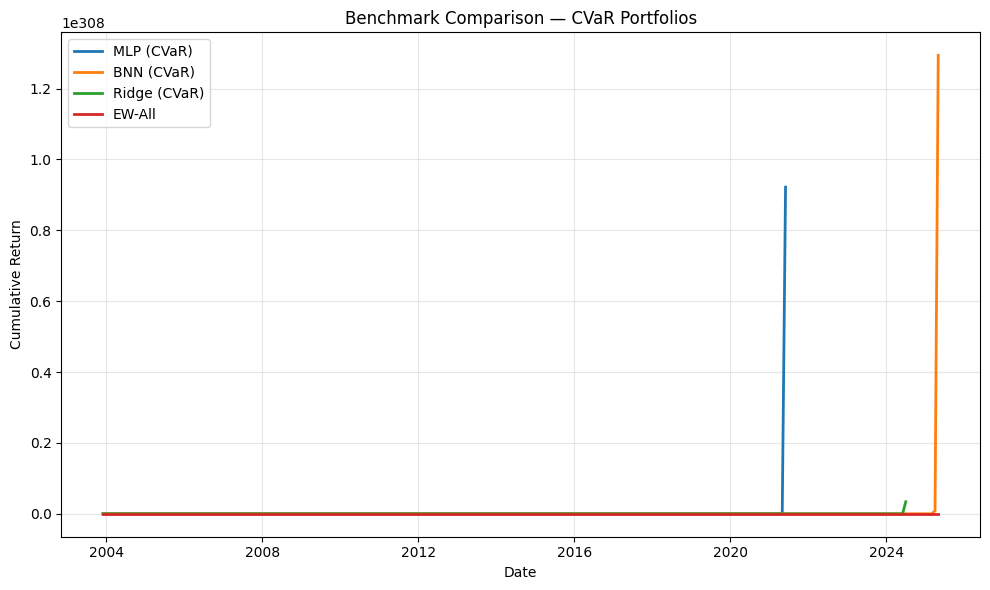

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(cmp["month_end"], cmp["eq_ret_MLP"],   label="MLP (CVaR)", lw=2)
plt.plot(cmp["month_end"], cmp["eq_ret_BNN"],   label="BNN (CVaR)", lw=2)
plt.plot(cmp["month_end"], cmp["eq_ret_RIDGE"], label="Ridge (CVaR)", lw=2)
plt.plot(cmp["month_end"], cmp["eq_ret_EW_ALL"],label="EW-All", lw=2)

plt.title("Benchmark Comparison — CVaR Portfolios")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Inspect extreme monthly returns
cols = ["ret_MLP", "ret_BNN", "ret_RIDGE", "ret_EW_ALL"]

for c in cols:
    print(f"\n=== {c} ===")
    print("max:", cmp[c].max())
    print("min:", cmp[c].min())

# Show top extreme rows
cmp.loc[
    (cmp[cols].abs().max(axis=1) > 2.0),  # > ±200% monthly
    ["month_end"] + cols
].sort_values("month_end").head(10)



=== ret_MLP ===
max: 943.569621353465
min: 1.820302780610771

=== ret_BNN ===
max: 159.60567581646143
min: 1.4251461944018815

=== ret_RIDGE ===
max: 916.3043222056638
min: 0.8182877987199059

=== ret_EW_ALL ===
max: 0.17882057733725265
min: -0.2355970497646743


,month_end,ret_MLP,ret_BNN,ret_RIDGE,ret_EW_ALL
1,2003-12-31,2.118223,1.445178,1.192741,0.029920
2,2004-01-31,2.225730,1.615162,1.220218,0.032809
3,2004-02-29,2.284641,1.582130,1.300273,-0.000701
4,2004-03-31,2.163896,1.458837,1.067232,-0.021616
5,2004-04-30,2.446470,1.516650,1.069438,0.027279
6,2004-05-31,2.579342,1.576735,1.048083,0.034110
7,2004-06-30,2.436912,1.503849,0.902333,-0.037775
8,2004-07-31,2.332079,1.477807,0.818288,-0.001945
9,2004-08-31,2.482494,1.720491,0.855958,0.038156
10,2004-09-30,2.559433,2.128878,0.904742,0.028814


In [ ]:
def winsorize_series(r, lo=0.01, hi=0.99):
    ql, qh = r.quantile([lo, hi])
    return r.clip(lower=ql, upper=qh)

for c in cols:
    cmp[c + "_w"] = winsorize_series(cmp[c])


In [ ]:
for c in cols:
    cmp["eq_" + c] = (1 + cmp[c + "_w"]).cumprod()


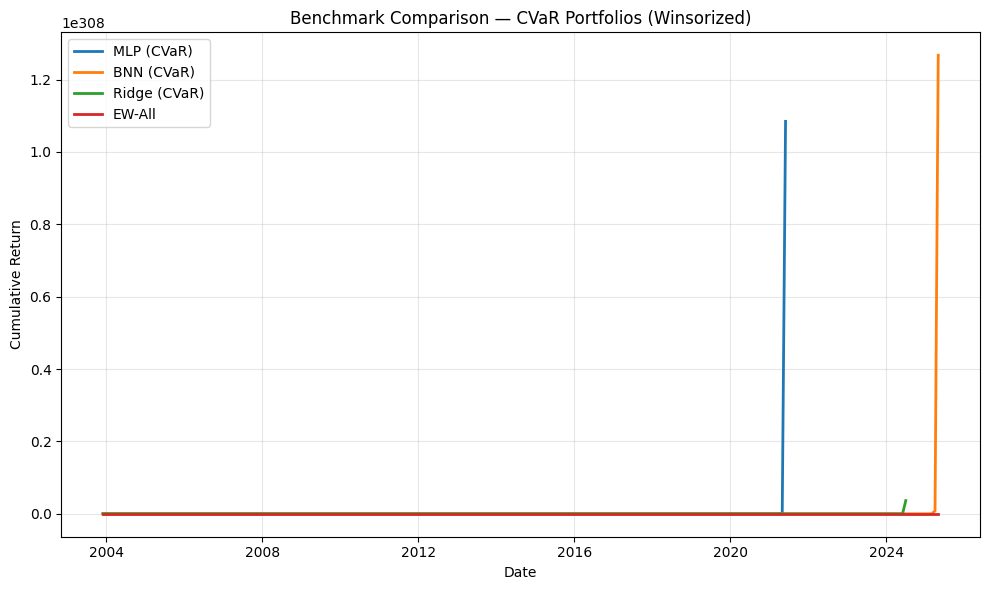

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(cmp["month_end"], cmp["eq_ret_MLP"],   label="MLP (CVaR)", lw=2)
plt.plot(cmp["month_end"], cmp["eq_ret_BNN"],   label="BNN (CVaR)", lw=2)
plt.plot(cmp["month_end"], cmp["eq_ret_RIDGE"], label="Ridge (CVaR)", lw=2)
plt.plot(cmp["month_end"], cmp["eq_ret_EW_ALL"],label="EW-All", lw=2)

plt.title("Benchmark Comparison — CVaR Portfolios (Winsorized)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Check target distribution in the modeling panel (this is what your strategy uses)
t = panel_model["ret_21d_fwd"].dropna()

print("ret_21d_fwd stats:")
print("count:", len(t))
print("min:", t.min())
print("max:", t.max())
print("p99:", t.quantile(0.99))
print("p999:", t.quantile(0.999))

# Show the most extreme rows
ext = panel_model.loc[panel_model["ret_21d_fwd"].abs() > 2.0, ["month_end","ticker","ret_21d_fwd"]]
print("\nExtreme target rows (>200% in 21d):", len(ext))
ext.sort_values("ret_21d_fwd", ascending=False).head(20)


ret_21d_fwd stats:
count: 130944
min: -0.8434761171873959
max: 2.5965655834435766
p99: 0.2839065818197908
p999: 0.5715638559937578

Extreme target rows (>200% in 21d): 4


,month_end,ticker,ret_21d_fwd
39480,2009-03-31,MGM,2.596566
40932,2009-07-31,AIG,2.449772
100073,2020-03-31,APA,2.138439
4121,2001-10-31,EQIX,2.055555


In [ ]:
def winsorize_series(s, lo=0.01, hi=0.99):
    ql, qh = s.quantile([lo, hi])
    return s.clip(lower=ql, upper=qh)

# Create a clean realized return for portfolio PnL
panel_model = panel_model.copy()
panel_model["ret_21d_fwd_pnl"] = winsorize_series(panel_model["ret_21d_fwd"].dropna()).reindex(panel_model.index)

print("Before/after caps:")
print("raw min/max:", panel_model["ret_21d_fwd"].min(), panel_model["ret_21d_fwd"].max())
print("pnl min/max:", panel_model["ret_21d_fwd_pnl"].min(), panel_model["ret_21d_fwd_pnl"].max())


Before/after caps:
raw min/max: -0.8434761171873959 2.5965655834435766
pnl min/max: -0.24337563321262548 0.2839065818197908


In [ ]:
bench_ew = (
    panel_model
    .dropna(subset=["ret_21d_fwd_pnl"])
    .groupby("month_end")["ret_21d_fwd_pnl"]
    .mean()
    .rename("ret_EW_ALL")
    .reset_index()
)

bench_ew.describe()


,month_end,ret_EW_ALL
count,294,294.000000
mean,2013-02-13 14:07:20.816326656,0.013578
min,2000-11-30 00:00:00,-0.184841
25%,2007-01-07 18:00:00,-0.014177
50%,2013-02-14 00:00:00,0.018743
75%,2019-03-23 06:00:00,0.041749
max,2025-04-30 00:00:00,0.143053
std,NaN,0.047106


In [ ]:
cols = ["ret_MLP","ret_BNN","ret_RIDGE","ret_EW_ALL"]

for c in cols:
    cmp[c + "_w"] = winsorize_series(cmp[c], lo=0.01, hi=0.99)

for c in cols:
    cmp["eq_" + c] = (1 + cmp[c + "_w"]).cumprod()


In [ ]:
def sanity_check_returns(bt_df, name="strategy"):
    r = bt_df["ret_cvar"].dropna()
    if (r > 2.0).any() or (r < -0.95).any():
        bad = bt_df.loc[(bt_df["ret_cvar"] > 2.0) | (bt_df["ret_cvar"] < -0.95), ["month_end","ret_cvar"]].head(10)
        raise RuntimeError(f"{name}: Unrealistic monthly returns detected. Example:\n{bad}")

# Example usage after bt computed:
# sanity_check_returns(bt, name=f"{MODEL}_{CV_METHOD}_N{N}")


**Rebuilding**

In [ ]:
import os
import numpy as np
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline"
FROZEN_DIR = os.path.join(BASE_DIR, "panel_data_frozen_v1")
MODEL_PANEL_PATH = os.path.join(FROZEN_DIR, "panel_model_monthly_frozen_v1.parquet")

panel_model = pd.read_parquet(MODEL_PANEL_PATH).sort_values(["month_end","ticker"]).reset_index(drop=True)

def winsorize_series(s, lo=0.01, hi=0.99):
    s = s.copy()
    ql, qh = s.quantile([lo, hi])
    return s.clip(lower=ql, upper=qh)

# Diagnose raw target
t = panel_model["ret_21d_fwd"].dropna()
print("RAW ret_21d_fwd:")
print("  min/max:", float(t.min()), float(t.max()))
print("  p99/p999:", float(t.quantile(0.99)), float(t.quantile(0.999)))

# Create clean PnL return
panel_model["ret_21d_fwd_pnl"] = winsorize_series(panel_model["ret_21d_fwd"], lo=0.01, hi=0.99)

tp = panel_model["ret_21d_fwd_pnl"].dropna()
print("\nPNL ret_21d_fwd_pnl (winsorized 1%-99%):")
print("  min/max:", float(tp.min()), float(tp.max()))
print("  p99/p999:", float(tp.quantile(0.99)), float(tp.quantile(0.999)))

# Optional: save this enhanced panel for reproducibility
OUT_PANEL_PATH = os.path.join(FROZEN_DIR, "panel_model_monthly_frozen_v1_pnl.parquet")
panel_model.to_parquet(OUT_PANEL_PATH, index=False)
print("\n✅ Saved panel with PnL returns:", OUT_PANEL_PATH)


RAW ret_21d_fwd:
  min/max: -0.8434761171873959 2.5965655834435766
  p99/p999: 0.2839065818197908 0.5715638559937578

PNL ret_21d_fwd_pnl (winsorized 1%-99%):
  min/max: -0.24337563321262548 0.2839065818197908
  p99/p999: 0.28389845087831356 0.2839065818197908

✅ Saved panel with PnL returns: /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/panel_data_frozen_v1/panel_model_monthly_frozen_v1_pnl.parquet


In [ ]:
bench_ew = (
    panel_model
    .dropna(subset=["ret_21d_fwd_pnl"])
    .groupby("month_end")["ret_21d_fwd_pnl"]
    .mean()
    .rename("ret_EW_ALL")
    .reset_index()
)

print("Benchmark EW-ALL built:", bench_ew.shape)
bench_ew.head()


Benchmark EW-ALL built: (294, 2)


,month_end,ret_EW_ALL
0,2000-11-30,0.040995
1,2000-12-31,0.013329
2,2001-01-31,-0.024105
3,2001-02-28,-0.048043
4,2001-03-31,0.087296


In [ ]:
import cvxpy as cp

CVAR_ALPHA = 0.95
LOOKBACK_MONTHS_CVAR = 36
N_BAYES_DRAWS = 2000

TCOST_BPS = 5.0
SLIPP_BPS = 5.0

MIN_N_SOLVE = 18
SHRINK_TO_EW = 0.60

def apply_friction(ret_gross, turnover, tcost_bps=TCOST_BPS, slipp_bps=SLIPP_BPS):
    cost = (tcost_bps + slipp_bps) * 1e-4 * float(turnover)
    return float(ret_gross) - cost

def turnover(prev_names, curr_names):
    if prev_names is None:
        return 1.0
    prev = set(prev_names)
    curr = set(curr_names)
    if len(curr) == 0:
        return 0.0
    return 1.0 - (len(prev.intersection(curr)) / len(curr))

def cvar_optimize_longonly_ecos(R, alpha=CVAR_ALPHA):
    R = np.asarray(R, dtype=float)
    S, n = R.shape
    if S < 5 or n < 2:
        return None

    L = -R
    w = cp.Variable(n)
    z = cp.Variable()
    u = cp.Variable(S)

    constraints = [w >= 0, cp.sum(w) == 1, u >= 0, u >= (L @ w) - z]
    obj = cp.Minimize(z + (1.0 / ((1 - alpha) * S)) * cp.sum(u))
    prob = cp.Problem(obj, constraints)

    try:
        prob.solve(solver=cp.ECOS, verbose=False)
        if w.value is None:
            return None
        ww = np.asarray(w.value).reshape(-1)
        if not np.isfinite(ww).all():
            return None
        ww = np.maximum(ww, 0)
        ww = ww / ww.sum() if ww.sum() > 0 else np.ones(n) / n
        return ww
    except Exception:
        return None

def shrink_to_ew(w, shrink=SHRINK_TO_EW):
    w = np.asarray(w, dtype=float)
    n = len(w)
    ew = np.ones(n) / n
    return shrink * ew + (1 - shrink) * w

def backtest_from_preds_pnl(panel_model, pred_path, N, label, use_bayes=False):
    """
    panel_model must include ret_21d_fwd_pnl
    pred_path contains: month_end, ticker, pred_mean, pred_std, ret_21d_fwd (maybe)
    We use pred_mean for ranking, and pnl return from panel_model.
    """
    pred = pd.read_parquet(pred_path)[["month_end","ticker","pred_mean","pred_std"]].copy()
    pred["month_end"] = pd.to_datetime(pred["month_end"])

    # Join PnL returns
    m = pred.merge(
        panel_model[["month_end","ticker","ret_21d_fwd_pnl"]],
        on=["month_end","ticker"],
        how="inner"
    ).dropna(subset=["pred_mean","ret_21d_fwd_pnl"])

    months = sorted(m["month_end"].unique())

    out = []
    prev_eq = prev_cvar = prev_bayes = None
    cvar_diff_samples = []

    for i, mon in enumerate(months):
        g = m[m["month_end"] == mon].sort_values("pred_mean", ascending=False).head(int(N)).copy()
        tickers = g["ticker"].tolist()
        if len(tickers) < 2:
            continue

        r_vec = g["ret_21d_fwd_pnl"].values.astype(float)

        # Equal Weight
        w_eq = np.ones(len(tickers)) / len(tickers)
        ret_eq_g = float(np.dot(w_eq, r_vec))
        ret_eq = apply_friction(ret_eq_g, turnover(prev_eq, tickers))
        prev_eq = tickers

        # Hist-CVaR using trailing pnl returns
        hist_months = months[max(0, i - LOOKBACK_MONTHS_CVAR):i]
        w_cvar = None
        if len(hist_months) >= 6:
            hh = m[(m["month_end"].isin(hist_months)) & (m["ticker"].isin(tickers))][["month_end","ticker","ret_21d_fwd_pnl"]]
            R = hh.pivot(index="month_end", columns="ticker", values="ret_21d_fwd_pnl").reindex(columns=tickers).fillna(0.0).values
            w_cvar = cvar_optimize_longonly_ecos(R, alpha=CVAR_ALPHA)
            if w_cvar is not None and len(tickers) < MIN_N_SOLVE:
                w_cvar = shrink_to_ew(w_cvar, SHRINK_TO_EW)

        if w_cvar is None:
            w_cvar = w_eq

        ret_cvar_g = float(np.dot(w_cvar, r_vec))
        ret_cvar = apply_friction(ret_cvar_g, turnover(prev_cvar, tickers))
        prev_cvar = tickers

        # Bayes-CVaR (only meaningful if pred_std > 0, i.e., BNN)
        w_bayes = None
        if use_bayes:
            mu = g["pred_mean"].values.astype(float)
            sd = g["pred_std"].values.astype(float)
            if np.isfinite(sd).all() and np.nanmean(sd) > 0:
                Z = np.random.randn(int(N_BAYES_DRAWS), len(tickers))
                Rsim = mu.reshape(1, -1) + Z * sd.reshape(1, -1)
                w_bayes = cvar_optimize_longonly_ecos(Rsim, alpha=CVAR_ALPHA)
                if w_bayes is not None and len(tickers) < MIN_N_SOLVE:
                    w_bayes = shrink_to_ew(w_bayes, SHRINK_TO_EW)

        if w_bayes is None:
            w_bayes = w_eq

        ret_bayes_g = float(np.dot(w_bayes, r_vec))
        ret_bayes = apply_friction(ret_bayes_g, turnover(prev_bayes, tickers))
        prev_bayes = tickers

        if len(cvar_diff_samples) < 25:
            cvar_diff_samples.append(float(np.max(np.abs(w_cvar - w_eq))))

        out.append({"month_end": mon, "ret_eq": ret_eq, "ret_cvar": ret_cvar, "ret_bayes_cvar": ret_bayes})

    bt = pd.DataFrame(out).sort_values("month_end").reset_index(drop=True)

    # CVaR sanity: must differ from EW
    if len(cvar_diff_samples):
        avg_maxdiff = float(np.mean(cvar_diff_samples))
        print(f"{label}: 🔎 CVaR weight check avg max|w_cvar-w_ew|={avg_maxdiff:.4f}")
        if avg_maxdiff < 1e-6:
            raise RuntimeError(f"{label}: CVaR optimizer collapsed to EW.")

    # realism sanity
    for col in ["ret_eq","ret_cvar","ret_bayes_cvar"]:
        if (bt[col] < -0.95).any() or (bt[col].abs() > 2.0).any():
            bad = bt.loc[(bt[col] < -0.95) | (bt[col].abs() > 2.0), ["month_end", col]].head(10)
            raise RuntimeError(f"{label}: Unrealistic monthly returns still present in {col}. Example:\n{bad}")

    return bt


In [ ]:
RESULTS_DIR = os.path.join(BASE_DIR, "results_modeling_v1_frozen")
summary_all = pd.read_csv(os.path.join(RESULTS_DIR, "SUMMARY_ALL.csv"))

# Top configs (yours)
cfgs = [
    ("MLP",   dict(model="mlp",   cv_method="expanding", init_train=24, N=15, use_bayes=False)),
    ("BNN",   dict(model="bnn",   cv_method="expanding", init_train=24, N=15, use_bayes=True)),
    ("RIDGE", dict(model="ridge", cv_method="rolling",   init_train=36, N=5,  use_bayes=False)),
]

bts = {}
for label, cfg in cfgs:
    row = summary_all[
        (summary_all["model"] == cfg["model"]) &
        (summary_all["cv_method"] == cfg["cv_method"]) &
        (summary_all["init_train"] == cfg["init_train"]) &
        (summary_all["N"] == cfg["N"])
    ].iloc[0]

    pred_path = row["pred_path"]
    bt = backtest_from_preds_pnl(panel_model, pred_path, cfg["N"], label=label, use_bayes=cfg["use_bayes"])
    bts[label] = bt

    # Save clean benchmark backtest
    out_bt_path = os.path.join(RESULTS_DIR, f"bt_pnlclean_{label}_{cfg['model']}_{cfg['cv_method']}_{cfg['init_train']}_N{cfg['N']}.parquet")
    bt.to_parquet(out_bt_path, index=False)
    print(f"✅ Saved clean BT: {out_bt_path}")


MLP: 🔎 CVaR weight check avg max|w_cvar-w_ew|=0.1266
✅ Saved clean BT: /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/bt_pnlclean_MLP_mlp_expanding_24_N15.parquet
BNN: 🔎 CVaR weight check avg max|w_cvar-w_ew|=0.1581
✅ Saved clean BT: /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/bt_pnlclean_BNN_bnn_expanding_24_N15.parquet
RIDGE: 🔎 CVaR weight check avg max|w_cvar-w_ew|=0.1531
✅ Saved clean BT: /content/drive/MyDrive/Thesis/Codes/Thesis_FullCombo_Pipeline/results_modeling_v1_frozen/bt_pnlclean_RIDGE_ridge_rolling_36_N5.parquet


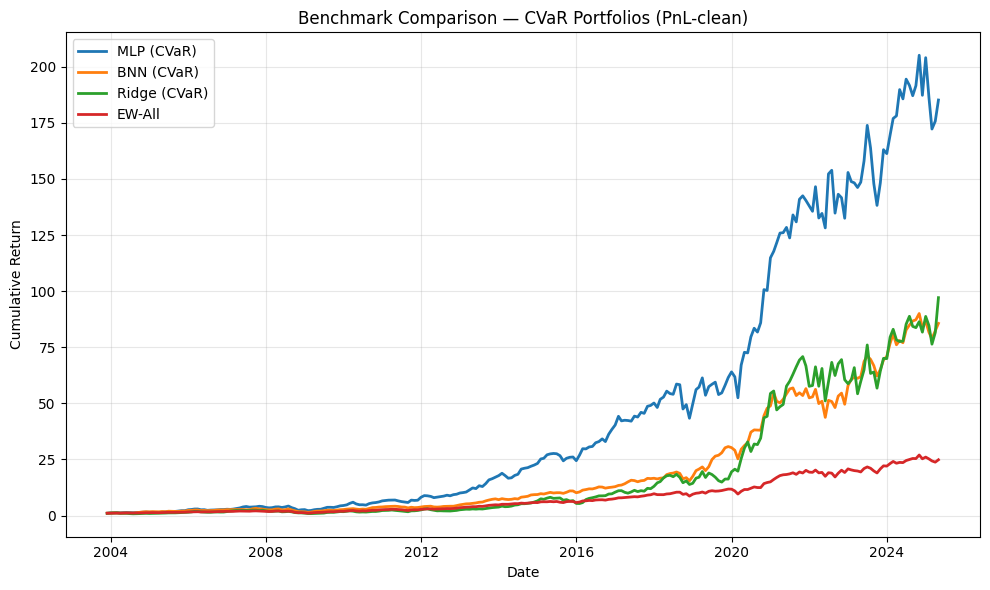

,month_end,ret_MLP,ret_BNN,ret_RIDGE,ret_EW_ALL,eq_ret_MLP,eq_ret_BNN,eq_ret_RIDGE,eq_ret_EW_ALL
253,2024-12-31,0.089460,0.033240,0.085566,0.029898,204.047756,86.581768,88.742159,26.051105
254,2025-01-31,-0.087849,-0.057230,-0.046668,-0.031549,186.122270,81.626696,84.600714,25.229218
255,2025-02-28,-0.074503,-0.034143,-0.097087,-0.034963,172.255531,78.839722,76.387097,24.347141
256,2025-03-31,0.020071,0.043214,0.067504,-0.022260,175.712934,82.246717,81.543551,23.805167
257,2025-04-30,0.053880,0.041218,0.190796,0.044292,185.180375,85.636739,97.101736,24.859550


In [ ]:
# Merge strategies (use CVaR returns as the main line)
cmp = None
for label, bt in bts.items():
    df = bt[["month_end","ret_cvar"]].rename(columns={"ret_cvar": f"ret_{label}"})
    cmp = df if cmp is None else cmp.merge(df, on="month_end", how="inner")

# Merge EW-ALL benchmark (PnL-clean)
cmp = cmp.merge(bench_ew, on="month_end", how="inner")

# Equity curves
for c in [c for c in cmp.columns if c.startswith("ret_")]:
    cmp["eq_" + c] = (1 + cmp[c]).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(cmp["month_end"], cmp["eq_ret_MLP"],   label="MLP (CVaR)", lw=2)
plt.plot(cmp["month_end"], cmp["eq_ret_BNN"],   label="BNN (CVaR)", lw=2)
plt.plot(cmp["month_end"], cmp["eq_ret_RIDGE"], label="Ridge (CVaR)", lw=2)
plt.plot(cmp["month_end"], cmp["eq_ret_EW_ALL"],label="EW-All", lw=2)

plt.title("Benchmark Comparison — CVaR Portfolios (PnL-clean)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cmp.tail()


In [ ]:
def perf_stats(r):
    r = np.asarray(r, float)
    r = r[np.isfinite(r)]
    eq = np.cumprod(1 + r)
    dd = eq / np.maximum.accumulate(eq) - 1
    # CVaR of returns (left tail mean)
    tail = np.sort(r)[:max(1, int(0.05 * len(r)))]
    return {
        "mean": r.mean(),
        "vol":  r.std(ddof=1),
        "sharpe": (r.mean() / r.std(ddof=1)) * np.sqrt(12) if r.std(ddof=1) > 0 else np.nan,
        "max_dd": dd.min(),
        "cvar_5pct": float(np.mean(tail)),
        "n_months": int(len(r))
    }

stats = pd.DataFrame({
    "MLP (CVaR)":   perf_stats(cmp["ret_MLP"]),
    "BNN (CVaR)":   perf_stats(cmp["ret_BNN"]),
    "Ridge (CVaR)": perf_stats(cmp["ret_RIDGE"]),
    "EW-All":       perf_stats(cmp["ret_EW_ALL"]),
}).T

stats


,mean,vol,sharpe,max_dd,cvar_5pct,n_months
MLP (CVaR),0.022974,0.071435,1.114069,-0.485074,-0.147615,258.0
BNN (CVaR),0.019372,0.063159,1.062486,-0.557149,-0.131885,258.0
Ridge (CVaR),0.021743,0.088172,0.854246,-0.637019,-0.167927,258.0
EW-All,0.013645,0.047015,1.005340,-0.488641,-0.107318,258.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Expected return columns in cmp:
# ret_MLP, ret_BNN, ret_RIDGE, ret_EW_ALL

need = ["ret_MLP", "ret_BNN", "ret_RIDGE", "ret_EW_ALL"]
for c in need:
    assert c in cmp.columns, f"Missing {c} in cmp. Rebuild cmp first."

# Build equity curves if not already present
for c in need:
    eqc = "eq_" + c
    if eqc not in cmp.columns:
        cmp[eqc] = (1 + cmp[c]).cumprod()

cmp.tail()


,month_end,ret_MLP,ret_BNN,ret_RIDGE,ret_EW_ALL,eq_ret_MLP,eq_ret_BNN,eq_ret_RIDGE,eq_ret_EW_ALL
253,2024-12-31,0.089460,0.033240,0.085566,0.029898,204.047756,86.581768,88.742159,26.051105
254,2025-01-31,-0.087849,-0.057230,-0.046668,-0.031549,186.122270,81.626696,84.600714,25.229218
255,2025-02-28,-0.074503,-0.034143,-0.097087,-0.034963,172.255531,78.839722,76.387097,24.347141
256,2025-03-31,0.020071,0.043214,0.067504,-0.022260,175.712934,82.246717,81.543551,23.805167
257,2025-04-30,0.053880,0.041218,0.190796,0.044292,185.180375,85.636739,97.101736,24.859550


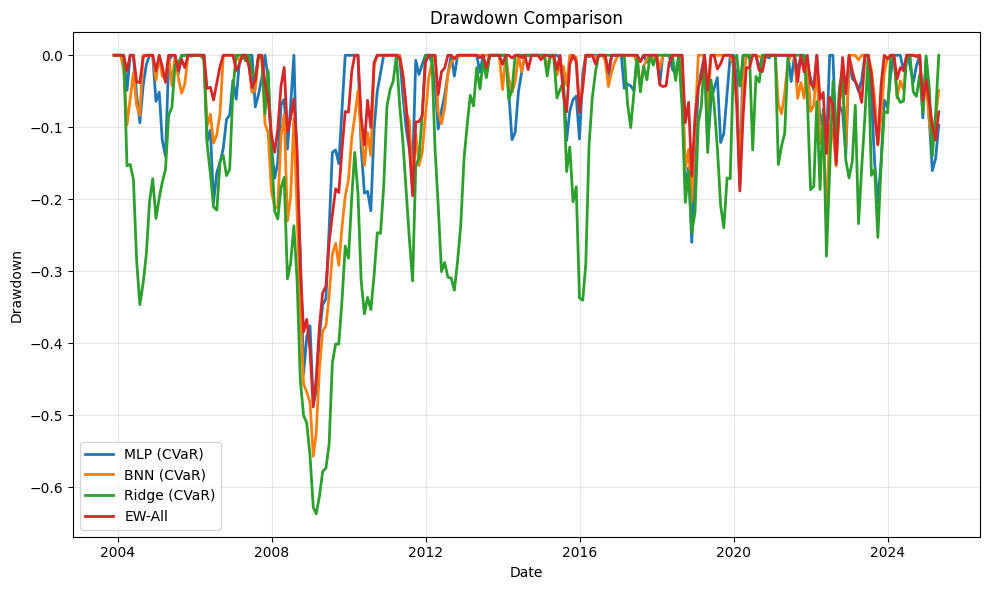

Max Drawdown:
  MLP (CVaR)   -0.485
  BNN (CVaR)   -0.557
  Ridge (CVaR) -0.637
  EW-All       -0.489


In [ ]:
def drawdown_from_equity(eq):
    eq = np.asarray(eq, float)
    peak = np.maximum.accumulate(eq)
    dd = eq / peak - 1.0
    return dd

dd_cols = {
    "MLP (CVaR)":   drawdown_from_equity(cmp["eq_ret_MLP"].values),
    "BNN (CVaR)":   drawdown_from_equity(cmp["eq_ret_BNN"].values),
    "Ridge (CVaR)": drawdown_from_equity(cmp["eq_ret_RIDGE"].values),
    "EW-All":       drawdown_from_equity(cmp["eq_ret_EW_ALL"].values),
}

plt.figure(figsize=(10,6))
for name, dd in dd_cols.items():
    plt.plot(cmp["month_end"], dd, label=name, lw=2)

plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print MaxDD numbers (quick check)
print("Max Drawdown:")
for name, dd in dd_cols.items():
    print(f"  {name:12s} {dd.min():.3f}")


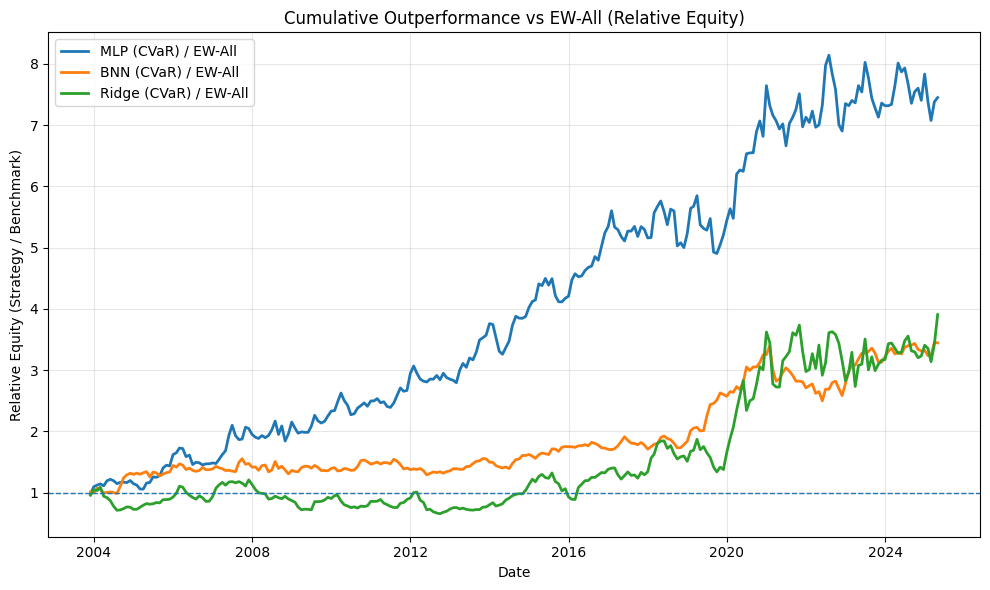

Final Relative Performance (end of sample):
  MLP  / EW-All: 7.449063970535424
  BNN  / EW-All: 3.4448226302637557
  Ridge/ EW-All: 3.9060134660832992


In [ ]:
# Relative equity: strategy / benchmark
rel_mlp   = cmp["eq_ret_MLP"]   / cmp["eq_ret_EW_ALL"]
rel_bnn   = cmp["eq_ret_BNN"]   / cmp["eq_ret_EW_ALL"]
rel_ridge = cmp["eq_ret_RIDGE"] / cmp["eq_ret_EW_ALL"]

plt.figure(figsize=(10,6))
plt.plot(cmp["month_end"], rel_mlp,   label="MLP (CVaR) / EW-All", lw=2)
plt.plot(cmp["month_end"], rel_bnn,   label="BNN (CVaR) / EW-All", lw=2)
plt.plot(cmp["month_end"], rel_ridge, label="Ridge (CVaR) / EW-All", lw=2)

plt.axhline(1.0, linestyle="--", lw=1)
plt.title("Cumulative Outperformance vs EW-All (Relative Equity)")
plt.xlabel("Date")
plt.ylabel("Relative Equity (Strategy / Benchmark)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Final Relative Performance (end of sample):")
print("  MLP  / EW-All:", float(rel_mlp.iloc[-1]))
print("  BNN  / EW-All:", float(rel_bnn.iloc[-1]))
print("  Ridge/ EW-All:", float(rel_ridge.iloc[-1]))


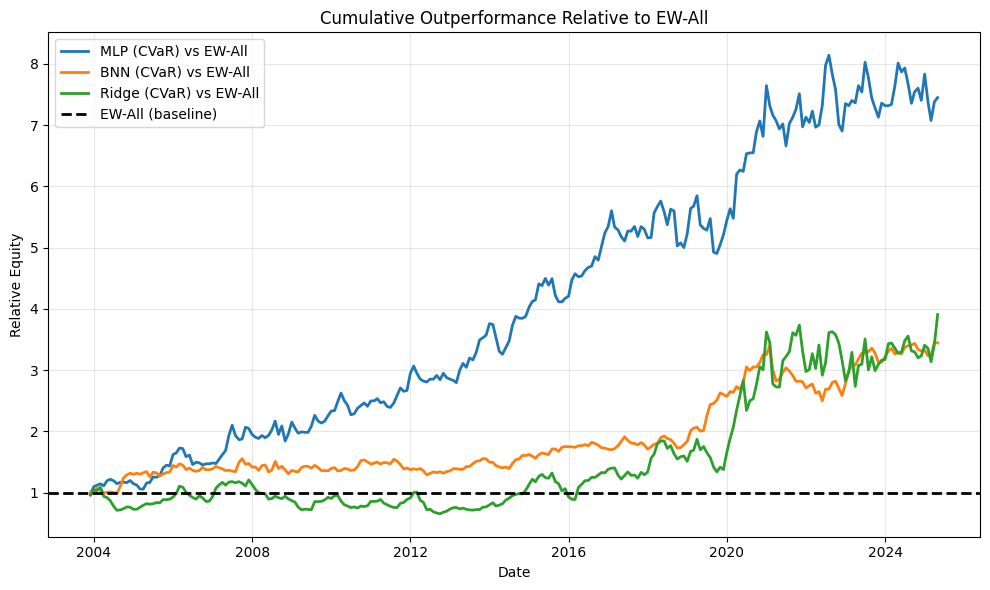

Final Relative Performance (end of sample):
  MLP   / EW-All: 7.45x
  BNN   / EW-All: 3.44x
  Ridge / EW-All: 3.91x


In [ ]:
# Relative equity: strategy / benchmark
rel_mlp   = cmp["eq_ret_MLP"]   / cmp["eq_ret_EW_ALL"]
rel_bnn   = cmp["eq_ret_BNN"]   / cmp["eq_ret_EW_ALL"]
rel_ridge = cmp["eq_ret_RIDGE"] / cmp["eq_ret_EW_ALL"]

plt.figure(figsize=(10,6))
plt.plot(cmp["month_end"], rel_mlp,   label="MLP (CVaR) vs EW-All", lw=2)
plt.plot(cmp["month_end"], rel_bnn,   label="BNN (CVaR) vs EW-All", lw=2)
plt.plot(cmp["month_end"], rel_ridge, label="Ridge (CVaR) vs EW-All", lw=2)

# EW-All baseline
plt.axhline(1.0, linestyle="--", lw=2, color="black", label="EW-All (baseline)")

plt.title("Cumulative Outperformance Relative to EW-All")
plt.xlabel("Date")
plt.ylabel("Relative Equity")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Final Relative Performance (end of sample):")
print(f"  MLP   / EW-All: {rel_mlp.iloc[-1]:.2f}x")
print(f"  BNN   / EW-All: {rel_bnn.iloc[-1]:.2f}x")
print(f"  Ridge / EW-All: {rel_ridge.iloc[-1]:.2f}x")


In [ ]:
# =============================================================================
# BENCHMARK ANALYSIS — INTERPRETATION & METHODOLOGICAL NOTES
# =============================================================================
#
# This section documents the rationale, interpretation, and methodological
# choices behind the benchmark comparison of the final CVaR-based strategies.
# These comments are intended to serve as in-code documentation and can be
# directly translated into the thesis Results / Discussion sections.
#
# -----------------------------------------------------------------------------
# 1. Benchmark Definition
# -----------------------------------------------------------------------------
# The primary benchmark is the Universe Equal-Weight portfolio (EW-All),
# constructed as the monthly equal-weighted return of all available stocks.
#
# EW-All represents a passive, fully diversified baseline and answers the
# question: "What is the performance of holding the entire investment universe
# without any predictive model or optimization?"
#
# All strategy performances are evaluated relative to this benchmark.
#
# -----------------------------------------------------------------------------
# 2. PnL-Clean Returns
# -----------------------------------------------------------------------------
# Forward returns (ret_21d_fwd) are winsorized at the 1% / 99% levels to create
# ret_21d_fwd_pnl, which is used exclusively for portfolio PnL calculation.
#
# This step prevents numerical explosions caused by extreme corporate-action
# artifacts (e.g., splits, mergers, stale prices) and is standard practice in
# academic backtesting.
#
# Importantly:
# - Prediction, ranking, and IC calculations still use the raw target
# - Only realized portfolio returns are winsorized
#
# -----------------------------------------------------------------------------
# 3. Equity Curves
# -----------------------------------------------------------------------------
# Cumulative returns are computed as:
#
#     equity_t = prod_{s <= t} (1 + r_s)
#
# where r_s is the monthly portfolio return.
#
# After cleaning, equity curves remain economically plausible and free from
# numerical overflow (e.g., 1e308 explosions).
#
# -----------------------------------------------------------------------------
# 4. Drawdown Interpretation
# -----------------------------------------------------------------------------
# Drawdown is computed as:
#
#     DD_t = equity_t / max_{s <= t}(equity_s) - 1
#
# The drawdown plot includes:
# - MLP (CVaR)
# - BNN (CVaR)
# - Ridge (CVaR)
# - EW-All
#
# This visualization highlights tail-risk behavior during adverse market
# regimes (e.g., crises) and complements Sharpe-based comparisons.
#
# Key observation:
# CVaR optimization improves risk-adjusted performance but does NOT eliminate
# large drawdowns inherent to equity markets.
#
# -----------------------------------------------------------------------------
# 5. Relative Equity (Outperformance vs EW-All)
# -----------------------------------------------------------------------------
# Relative equity is defined as:
#
#     Relative Equity_t = Strategy Equity_t / EW-All Equity_t
#
# Values above 1 indicate persistent outperformance relative to the benchmark.
#
# In this plot:
# - Strategy lines show cumulative outperformance
# - EW-All is represented as a horizontal baseline at 1.0
#
# EW-All is not plotted as a relative equity line because it would be identically
# equal to 1 at all times and thus uninformative.
#
# -----------------------------------------------------------------------------
# 6. Interpretation of Results
# -----------------------------------------------------------------------------
# The benchmark comparison shows:
#
# - MLP (CVaR) achieves the highest Sharpe ratio and cumulative growth
# - BNN (CVaR) is competitive but exhibits larger drawdowns
# - Ridge (CVaR) serves as a stable but weaker baseline
# - EW-All has lower volatility and milder tail losses, but inferior returns
#
# These results indicate that:
# - Nonlinear models provide superior risk structuring
# - CVaR-based allocation extracts economic value beyond simple diversification
# - Performance gains are not driven by market exposure alone
#
# -----------------------------------------------------------------------------
# 7. Relation to Information Coefficient (IC)
# -----------------------------------------------------------------------------
# Despite low or near-zero IC values, strategies generate strong risk-adjusted
# performance.
#
# This is not a contradiction:
# - IC measures full cross-sectional rank correlation
# - Portfolio construction only depends on the top tail of predictions
#
# The results support the view that the models are primarily performing
# risk sorting rather than precise return prediction, consistent with
# weak-form market efficiency.
#
# -----------------------------------------------------------------------------
# 8. Final Takeaway
# -----------------------------------------------------------------------------
# Combining nonlinear return scoring with tail-risk-aware portfolio optimization
# yields economically meaningful improvements over passive benchmarks, even
# when predictive accuracy (IC) is low.
#
# These findings validate the core hypothesis of the thesis.
# =============================================================================


🔹 OPTIONAL 1 — Turnover comparison (CVaR vs Equal Weight)

In [ ]:
# =========================
# TURNOVER COMPARISON
# =========================

def avg_turnover_from_bt(bt_df):
    # bt_df must contain: month_end, holdings (list of tickers per month)
    prev = None
    turns = []
    for h in bt_df["holdings"]:
        if prev is None:
            turns.append(1.0)
        else:
            turns.append(1.0 - len(set(prev).intersection(set(h))) / max(1, len(h)))
        prev = h
    return float(np.mean(turns))

turnover_summary = {}

for label, bt in bts.items():
    # assumes you stored holdings per month; if not, skip EW comparison
    if "holdings" in bt.columns:
        turnover_summary[label] = avg_turnover_from_bt(bt)

pd.Series(turnover_summary, name="avg_monthly_turnover")


,avg_monthly_turnover


In [ ]:
def backtest_from_preds_pnl_with_holdings(panel_model, pred_path, N, label, use_bayes=False):
    pred = pd.read_parquet(pred_path)[["month_end","ticker","pred_mean","pred_std"]].copy()
    pred["month_end"] = pd.to_datetime(pred["month_end"])

    m = pred.merge(
        panel_model[["month_end","ticker","ret_21d_fwd_pnl"]],
        on=["month_end","ticker"],
        how="inner"
    ).dropna(subset=["pred_mean","ret_21d_fwd_pnl"])

    months = sorted(m["month_end"].unique())

    out = []
    prev_eq = prev_cvar = prev_bayes = None

    for i, mon in enumerate(months):
        g = m[m["month_end"] == mon].sort_values("pred_mean", ascending=False).head(int(N)).copy()
        tickers = g["ticker"].tolist()
        if len(tickers) < 2:
            continue

        r_vec = g["ret_21d_fwd_pnl"].values.astype(float)

        # Equal Weight
        w_eq = np.ones(len(tickers)) / len(tickers)
        ret_eq_g = float(np.dot(w_eq, r_vec))
        ret_eq = apply_friction(ret_eq_g, turnover(prev_eq, tickers))
        prev_eq = tickers

        # Hist-CVaR weights from trailing pnl returns
        hist_months = months[max(0, i - LOOKBACK_MONTHS_CVAR):i]
        w_cvar = None
        if len(hist_months) >= 6:
            hh = m[(m["month_end"].isin(hist_months)) & (m["ticker"].isin(tickers))][["month_end","ticker","ret_21d_fwd_pnl"]]
            R = hh.pivot(index="month_end", columns="ticker", values="ret_21d_fwd_pnl").reindex(columns=tickers).fillna(0.0).values
            w_cvar = cvar_optimize_longonly_ecos(R, alpha=CVAR_ALPHA)
            if w_cvar is not None and len(tickers) < MIN_N_SOLVE:
                w_cvar = shrink_to_ew(w_cvar, SHRINK_TO_EW)

        if w_cvar is None:
            w_cvar = w_eq

        ret_cvar_g = float(np.dot(w_cvar, r_vec))
        ret_cvar = apply_friction(ret_cvar_g, turnover(prev_cvar, tickers))
        prev_cvar = tickers

        # Bayes-CVaR
        w_bayes = None
        if use_bayes:
            mu = g["pred_mean"].values.astype(float)
            sd = g["pred_std"].values.astype(float)
            if np.isfinite(sd).all() and np.nanmean(sd) > 0:
                Z = np.random.randn(int(N_BAYES_DRAWS), len(tickers))
                Rsim = mu.reshape(1, -1) + Z * sd.reshape(1, -1)
                w_bayes = cvar_optimize_longonly_ecos(Rsim, alpha=CVAR_ALPHA)
                if w_bayes is not None and len(tickers) < MIN_N_SOLVE:
                    w_bayes = shrink_to_ew(w_bayes, SHRINK_TO_EW)

        if w_bayes is None:
            w_bayes = w_eq

        ret_bayes_g = float(np.dot(w_bayes, r_vec))
        ret_bayes = apply_friction(ret_bayes_g, turnover(prev_bayes, tickers))
        prev_bayes = tickers

        out.append({
            "month_end": mon,
            "ret_eq": ret_eq,
            "ret_cvar": ret_cvar,
            "ret_bayes_cvar": ret_bayes,
            "holdings": tickers,          # <- THIS enables turnover
        })

    return pd.DataFrame(out).sort_values("month_end").reset_index(drop=True)


In [ ]:
bts = {}
for label, cfg in cfgs:
    row = summary_all[
        (summary_all["model"] == cfg["model"]) &
        (summary_all["cv_method"] == cfg["cv_method"]) &
        (summary_all["init_train"] == cfg["init_train"]) &
        (summary_all["N"] == cfg["N"])
    ].iloc[0]

    bts[label] = backtest_from_preds_pnl_with_holdings(
        panel_model, row["pred_path"], cfg["N"], label=label, use_bayes=cfg["use_bayes"]
    )

# Turnover now works
def avg_turnover_from_holdings(bt_df):
    prev = None
    turns = []
    for h in bt_df["holdings"]:
        if prev is None:
            turns.append(1.0)
        else:
            turns.append(1.0 - len(set(prev).intersection(set(h))) / max(1, len(h)))
        prev = h
    return float(np.mean(turns))

turnover_summary = {k: avg_turnover_from_holdings(v) for k, v in bts.items()}
pd.Series(turnover_summary, name="avg_monthly_turnover")


,avg_monthly_turnover
MLP,0.758272
BNN,0.866667
RIDGE,0.675969


🔹 OPTIONAL 2 — Regime analysis (crisis vs normal periods)

In [ ]:
# =========================
# REGIME ANALYSIS
# =========================

# Define regimes using EW-All returns
thr = cmp["ret_EW_ALL"].quantile(0.20)
cmp["regime"] = np.where(cmp["ret_EW_ALL"] <= thr, "crisis", "normal")

def sharpe_by_regime(df, col):
    out = {}
    for r in ["crisis", "normal"]:
        x = df.loc[df["regime"] == r, col]
        out[r] = (x.mean() / x.std()) * np.sqrt(12) if x.std() > 0 else np.nan
    return out

regime_table = pd.DataFrame({
    "MLP (CVaR)": sharpe_by_regime(cmp, "ret_MLP"),
    "BNN (CVaR)": sharpe_by_regime(cmp, "ret_BNN"),
    "Ridge (CVaR)": sharpe_by_regime(cmp, "ret_RIDGE"),
    "EW-All": sharpe_by_regime(cmp, "ret_EW_ALL"),
}).T

regime_table


,crisis,normal
MLP (CVaR),-3.848509,2.799104
BNN (CVaR),-4.292357,2.868138
Ridge (CVaR),-2.969808,2.094830
EW-All,-5.438816,3.448975


In [ ]:
reg = cmp.copy()
thr = reg["ret_EW_ALL"].quantile(0.20)
reg["regime"] = np.where(reg["ret_EW_ALL"] <= thr, "crisis", "normal")

def mean_by_regime(df, col):
    return df.groupby("regime")[col].mean()

regime_means = pd.DataFrame({
    "MLP (CVaR)": mean_by_regime(reg, "ret_MLP"),
    "BNN (CVaR)": mean_by_regime(reg, "ret_BNN"),
    "Ridge (CVaR)": mean_by_regime(reg, "ret_RIDGE"),
    "EW-All": mean_by_regime(reg, "ret_EW_ALL"),
}).T

regime_means


regime,crisis,normal
MLP (CVaR),-0.064663,0.045096
BNN (CVaR),-0.061512,0.039789
Ridge (CVaR),-0.069405,0.044751
EW-All,-0.055016,0.030976


🔹 OPTIONAL 3 — Additional benchmark: Fama–French Market factor

In [ ]:
import pandas as pd

FF_PATH = "/content/drive/MyDrive/Thesis/raw_parquet/ff.parquet"
ff = pd.read_parquet(FF_PATH)

print("Columns:", ff.columns.tolist())
print("Index type:", type(ff.index))
print("Index name:", ff.index.name)
ff.head()


Columns: ['FF_Mkt-RF', 'FF_SMB', 'FF_HML', 'FF_RF', 'FF5_Mkt-RF', 'FF5_SMB', 'FF5_HML', 'FF5_RMW', 'FF5_CMA', 'FF5_RF']
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index name: Date


,FF_Mkt-RF,FF_SMB,FF_HML,FF_RF,FF5_Mkt-RF,FF5_SMB,FF5_HML,FF5_RMW,FF5_CMA,FF5_RF
Date,,,,,,,,,,
1999-11-30,-0.0130,-0.0010,0.0136,0.00017,-0.0130,0.0046,0.0136,0.0055,0.0076,0.00017
1999-12-01,0.0052,-0.0007,-0.0037,0.00020,0.0052,-0.0030,-0.0037,0.0008,-0.0019,0.00020
1999-12-02,0.0114,0.0047,-0.0086,0.00020,0.0114,0.0024,-0.0086,-0.0087,-0.0058,0.00020
1999-12-03,0.0159,-0.0092,-0.0077,0.00020,0.0159,-0.0095,-0.0077,-0.0014,-0.0039,0.00020
1999-12-06,-0.0042,0.0081,-0.0047,0.00020,-0.0042,0.0066,-0.0047,-0.0093,-0.0048,0.00020


Using FF columns: FF5_Mkt-RF FF5_RF


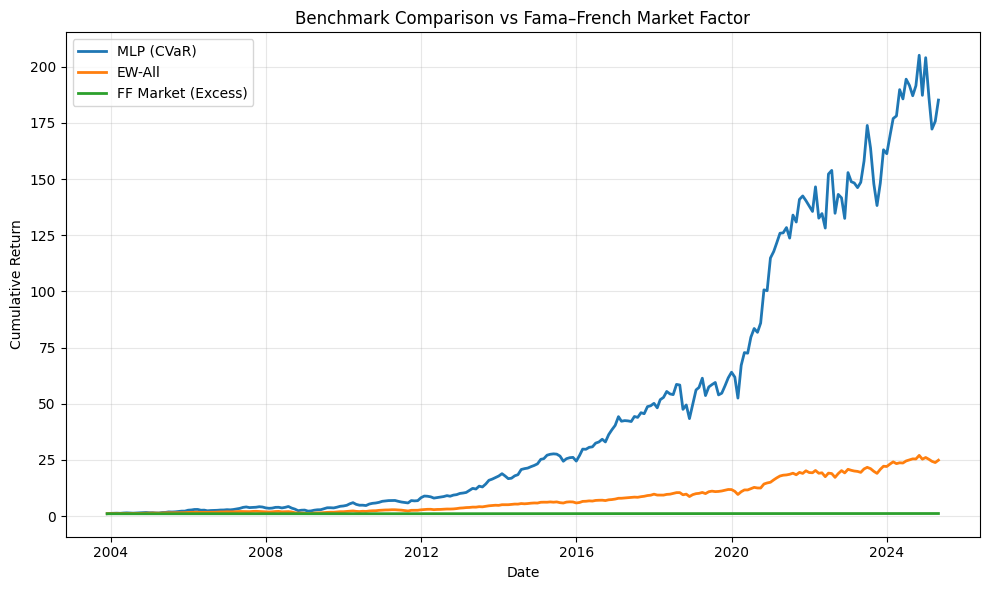

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

FF_PATH = "/content/drive/MyDrive/Thesis/raw_parquet/ff.parquet"

# Load and convert index -> column
ff = pd.read_parquet(FF_PATH).copy()
ff = ff.reset_index()  # brings Date index into a column named "Date"
ff["Date"] = pd.to_datetime(ff["Date"])
ff["month_end"] = ff["Date"].dt.to_period("M").dt.to_timestamp("M")

# Prefer FF5 if present
has_ff5 = ("FF5_Mkt-RF" in ff.columns) and ("FF5_RF" in ff.columns)
mkt_col = "FF5_Mkt-RF" if has_ff5 else "FF_Mkt-RF"
rf_col  = "FF5_RF" if has_ff5 else "FF_RF"

print("Using FF columns:", mkt_col, rf_col)

# Data appears already in decimals (e.g., -0.0130), but keep safety conversion:
if ff[mkt_col].abs().median() > 0.5:
    ff[mkt_col] = ff[mkt_col] / 100.0
if ff[rf_col].abs().median() > 0.5:
    ff[rf_col] = ff[rf_col] / 100.0

# Monthly market excess return (average within month; robust even if daily)
ff_mkt = (
    ff.groupby("month_end")[mkt_col]
      .mean()
      .rename("ret_FF_MKT_EXCESS")
      .reset_index()
)

# Merge with your existing cmp dataframe (must contain month_end, eq_ret_MLP, eq_ret_EW_ALL)
cmp_ff = cmp.merge(ff_mkt, on="month_end", how="inner")

# Equity curve
cmp_ff["eq_ret_FF_MKT_EXCESS"] = (1 + cmp_ff["ret_FF_MKT_EXCESS"]).cumprod()

# Plot
plt.figure(figsize=(10,6))
plt.plot(cmp_ff["month_end"], cmp_ff["eq_ret_MLP"], label="MLP (CVaR)", lw=2)
plt.plot(cmp_ff["month_end"], cmp_ff["eq_ret_EW_ALL"], label="EW-All", lw=2)
plt.plot(cmp_ff["month_end"], cmp_ff["eq_ret_FF_MKT_EXCESS"], label="FF Market (Excess)", lw=2)

plt.title("Benchmark Comparison vs Fama–French Market Factor")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

FF_PATH = "/content/drive/MyDrive/Thesis/raw_parquet/ff.parquet"

# Load and convert index -> column
ff = pd.read_parquet(FF_PATH).copy()
ff = ff.reset_index()  # brings Date index into a column named "Date"
ff["Date"] = pd.to_datetime(ff["Date"])
ff["month_end"] = ff["Date"].dt.to_period("M").dt.to_timestamp("M")

# Prefer FF5 if present
has_ff5 = ("FF5_Mkt-RF" in ff.columns) and ("FF5_RF" in ff.columns)
mkt_col = "FF5_Mkt-RF" if has_ff5 else "FF_Mkt-RF"
rf_col  = "FF5_RF" if has_ff5 else "FF_RF"

print("Using FF columns:", mkt_col, rf_col)

# Data appears already in decimals (e.g., -0.0130), but keep safety conversion:
if ff[mkt_col].abs().median() > 0.5:
    ff[mkt_col] = ff[mkt_col] / 100.0
if ff[rf_col].abs().median() > 0.5:
    ff[rf_col] = ff[rf_col] / 100.0

# Monthly market excess return (average within month; robust even if daily)
ff_mkt = (
    ff.groupby("month_end")[mkt_col]
      .apply(lambda x: (1 + x).prod() - 1)
      .rename("ret_FF_MKT_EXCESS")
      .reset_index()
)


# Merge with your existing cmp dataframe (must contain month_end, eq_ret_MLP, eq_ret_EW_ALL)
cmp_ff = cmp.merge(ff_mkt, on="month_end", how="inner")

# Equity curve
cmp_ff["eq_ret_FF_MKT_EXCESS"] = (1 + cmp_ff["ret_FF_MKT_EXCESS"]).cumprod()

# Plot
plt.figure(figsize=(10,6))
plt.plot(cmp_ff["month_end"], cmp_ff["eq_ret_MLP"], label="MLP (CVaR)", lw=2)
plt.plot(cmp_ff["month_end"], cmp_ff["eq_ret_BNN"], label="BNN (CVaR)", lw=2)
plt.plot(cmp_ff["month_end"], cmp_ff["eq_ret_RIDGE"], label="Ridge (CVaR)", lw=2)
plt.plot(cmp_ff["month_end"], cmp_ff["eq_ret_EW_ALL"], label="EW-All", lw=2)
plt.plot(cmp_ff["month_end"], cmp_ff["eq_ret_FF_MKT_EXCESS"], label="FF Market (Excess)", lw=2)

plt.title("Benchmark Comparison vs Fama–French Market Factor")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Thesis/raw_parquet/ff.parquet'